# MVP — Machine Learning & Analytics

**Nome:** _Aline Bastos Brasil_  
**Matrícula:** _17357176738_  
**Data:** _01/07/2026_  
**Dataset:** _IBM Telco Customer Churn Dataset_
**Fonte:** _https://github.com/IBM/telco-customer-churn-on-icp4d_  
**Tipo de problema:** _Classificação Binária_  


---


# 1. Definição do problema

## 1.1 Descrição do problema

A evasão de clientes (customer churn) é um desafio comum para empresas que oferecem serviços por assinatura, pois o cancelamento de contratos pode reduzir a receita e aumentar os custos para aquisição de novos clientes.

Neste projeto, será desenvolvido um modelo de Machine Learning para prever a probabilidade de um cliente cancelar o serviço com base em informações demográficas, contratuais e sobre os serviços contratados. O objetivo é apoiar a identificação antecipada de clientes com maior risco de cancelamento.

Essa informação pode auxiliar equipes de negócio, marketing e relacionamento com o cliente na definição de estratégias de retenção, permitindo direcionar ações para os clientes com maior probabilidade de evasão.

Esse problema é relevante porque a retenção de clientes costuma ser mais econômica do que a aquisição de novos clientes, tornando a previsão de churn uma ferramenta importante para apoiar a tomada de decisão nas organizações.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever o cancelamento de clientes (customer churn) a partir de informações demográficas, cadastrais e contratuais, comparando um modelo baseline com modelos candidatos e analisando seus resultados por meio de métricas adequadas para um problema de classificação.

## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação Binária_  
**Justificativa:** _O objetivo do modelo é prever se um cliente irá cancelar ou permanecer no serviço, representado pela variável-alvo **Churn**, que possui duas classes possíveis ("Yes" e "No"). Como a saída esperada é uma categoria e não um valor numérico contínuo, o problema é caracterizado como uma tarefa de classificação binária._



## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. _As informações disponíveis sobre os clientes são suficientes para identificar padrões relacionados ao cancelamento do serviço._
2. _Modelos de Machine Learning conseguem aprender esses padrões e realizar previsões melhores do que uma estratégia simples (modelo baseline)._
3. _O tratamento adequado dos dados, como a preparação das variáveis antes do treinamento, pode contribuir para melhorar o desempenho dos modelos._


**Critérios de sucesso:**
- Métrica principal: _Será utilizado o F1-score, uma métrica bastante utilizada em problemas de classificação binária. Ela combina duas medidas importantes: a precisão (precision), que indica quantas das previsões positivas feitas pelo modelo estavam corretas, e o recall, que mede quantos dos casos positivos existentes foram realmente identificados pelo modelo. Como essas duas medidas são igualmente importantes neste problema, o F1-score fornece uma avaliação mais equilibrada do desempenho do modelo do que utilizar apenas a acurácia._
- Resultado mínimo esperado: _Obter um desempenho superior ao modelo baseline utilizando a métrica F1-score._
- Restrição prática: _Os modelos escolhidos devem apresentar tempo de treinamento compatível com um MVP, além de permitir que seus resultados sejam reproduzidos e interpretados com facilidade._


# 2. Ambiente, bibliotecas e reprodutibilidade

Nesta seção serão apresentadas as bibliotecas utilizadas ao longo do desenvolvimento do projeto, bem como as configurações adotadas para garantir a reprodutibilidade dos resultados.

Em projetos de Machine Learning, é comum que algumas etapas utilizem processos aleatórios, como a divisão dos dados em conjuntos de treino e teste ou o treinamento de determinados algoritmos. Para que os resultados possam ser reproduzidos por outras pessoas, será definida uma **seed** (semente) fixa, reduzindo a variação causada por esses processos.

O desenvolvimento deste MVP será realizado no **Google Colab**, utilizando as bibliotecas disponíveis nesse ambiente. Como o conjunto de dados possui um volume relativamente pequeno e os modelos escolhidos apresentam baixo custo computacional, não será necessária a utilização de GPU, sendo a execução em CPU suficiente para este projeto.

Ao longo do notebook, serão utilizadas bibliotecas para manipulação e análise de dados, visualização gráfica e construção dos modelos de Machine Learning. As principais versões das bibliotecas utilizadas também serão apresentadas, contribuindo para a reprodutibilidade do experimento.


In [666]:
# ============================================================
# Bibliotecas padrão do Python
# Utilizadas para configurações do ambiente, controle de avisos
# e definição da seed para garantir a reprodutibilidade.
# ============================================================
import random
import sys
import time
import warnings

# ============================================================
# Manipulação e análise de dados
# Bibliotecas utilizadas para carregar, organizar, manipular
# e analisar os dados ao longo do projeto.
# ============================================================
import numpy as np
import pandas as pd

# ============================================================
# Visualização de dados
# Bibliotecas utilizadas para criar gráficos que auxiliam na
# análise exploratória e interpretação dos resultados.
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# Biblioteca utilizada para construção, treinamento e avaliação
# dos modelos de Machine Learning.
# ============================================================
import sklearn

# ============================================================
# Pré-processamento dos dados
# Ferramentas utilizadas para preparar os dados antes do
# treinamento dos modelos.
# ============================================================
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# ============================================================
# Divisão dos dados e validação
# Responsáveis por separar os dados em treino e teste e por
# realizar a validação durante o ajuste dos modelos.
# ============================================================
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedKFold,
    train_test_split
)

# ============================================================
# Modelos de Machine Learning
# Algoritmos que serão utilizados como modelo baseline e
# modelos candidatos para resolver o problema de classificação.
# ============================================================
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# ============================================================
# Avaliação dos modelos
# Métricas e recursos gráficos utilizados para comparar o
# desempenho dos modelos treinados.
# ============================================================
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)

# ============================================================
# Persistência de artefatos
# Biblioteca utilizada para salvar e reutilizar o modelo final
# e outros objetos produzidos durante o projeto.
# ============================================================
import joblib

# ============================================================
# Configuração do ambiente
# Essas configurações tornam o notebook mais organizado e
# contribuem para que os resultados possam ser reproduzidos.
# ============================================================

# Oculta avisos que não interferem na execução do projeto.
warnings.filterwarnings("ignore")

# Define uma seed fixa para tornar os resultados reproduzíveis.
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

# ============================================================
# Informações do ambiente
# Exibe as versões das principais bibliotecas utilizadas no
# projeto, facilitando a reprodução dos experimentos.
# ============================================================
print(f"Versão do Python: {sys.version.split()[0]}")
print(f"Versão do Pandas: {pd.__version__}")
print(f"Versão do NumPy: {np.__version__}")
print(f"Versão do Scikit-learn: {sklearn.__version__}")
print(f"Seed utilizada: {RANDOM_STATE}")

Versão do Python: 3.12.13
Versão do Pandas: 2.2.2
Versão do NumPy: 2.0.2
Versão do Scikit-learn: 1.6.1
Seed utilizada: 42


## 2.1 Dependências adicionais

Não foi necessária a instalação de bibliotecas adicionais para o desenvolvimento deste MVP.

Todas as bibliotecas utilizadas fazem parte do ambiente padrão do Google Colab e foram importadas com sucesso na etapa anterior. Essa escolha reduz a necessidade de configurações extras, facilita a reprodução dos experimentos e aumenta a probabilidade de que o notebook seja executado corretamente em outros ambientes.

## 2.2 Funções auxiliares

Ao longo do desenvolvimento deste MVP, poderão ser criadas funções auxiliares para evitar repetição de código, melhorar a organização do notebook e facilitar sua manutenção.

No entanto, como a definição das métricas de avaliação, dos modelos e das etapas de processamento depende dos resultados obtidos durante a Análise Exploratória dos Dados (Exploratory Data Analysis – EDA), essas funções serão implementadas nas seções em que sua utilização contribuir para a organização, reutilização e legibilidade do código.

Essa abordagem evita a criação de funções que possam não ser utilizadas ou que precisem ser modificadas durante o desenvolvimento, mantendo o código mais consistente e alinhado às decisões tomadas ao longo do projeto.


In [667]:
# ============================================================
# Funções auxiliares
# ============================================================


# ============================================================
# Função auxiliar para formatação de gráficos de contagem
# Ajusta títulos, rótulos dos eixos e adiciona os valores sobre as barras.
# ============================================================

def format_countplot(ax):
    """
    Aplica a formatação padrão aos gráficos de barras utilizados
    neste notebook.
    """

    # Exibe os valores sobre cada barra.
    for container in ax.containers:
        ax.bar_label(container)

    # Adiciona uma grade horizontal para facilitar a leitura.
    plt.grid(axis="y", linestyle="--", alpha=0.4)

    # Remove bordas desnecessárias do gráfico.
    sns.despine()

    # Ajusta automaticamente os espaçamentos da figura.
    plt.tight_layout()

# ============================================================
# Função auxiliar para gráficos de barras empilhadas
# Calcula e exibe a distribuição percentual entre categorias,
# incluindo rótulos, legendas e percentuais nas barras.
# ============================================================

def plot_stacked_percentage(
    df,
    feature,
    target="Churn",
    figsize=(8, 5),
    dpi=120
):
    """
    Exibe um gráfico de barras empilhadas em percentual (100%)
    entre uma variável categórica e a variável-alvo.

    Parâmetros
    ----------
    df : pandas.DataFrame
        DataFrame contendo os dados.

    feature : str
        Variável categórica a ser analisada.

    target : str, default="Churn"
        Nome da variável-alvo.

    figsize : tuple, default=(8, 5)
        Tamanho da figura.

    dpi : int, default=120
        Resolução da figura.
    """

    # ========================================================
    # Calcula o percentual de cada classe da variável-alvo
    # dentro de cada categoria da variável analisada.
    # ========================================================

    percentage_table = (
        pd.crosstab(
            df[feature],
            df[target],
            normalize="index"
        )
        * 100
    )

    # Mantém a ordem original das categorias
    percentage_table = percentage_table.reindex(
        df[feature].drop_duplicates()
    )

    # Obtém automaticamente as classes da variável-alvo.
    target_classes = percentage_table.columns.tolist()

    # ========================================================
    # Criação da figura
    # ========================================================

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=dpi
    )

    bottom = np.zeros(len(percentage_table))

    # ========================================================
    # Plota cada classe da variável-alvo
    # ========================================================

    for target_class in target_classes:

        values = percentage_table[target_class]

        ax.bar(
            percentage_table.index,
            values,
            bottom=bottom,
            label=TARGET_LABELS.get(target_class, target_class)
        )

        # Exibe os percentuais apenas quando houver espaço
        for i, value in enumerate(values):

            if value >= 5:

                ax.text(
                    x=i,
                    y=bottom[i] + value / 2,
                    s=f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color="white"
                )

        bottom += values.values

    # ========================================================
    # Tradução das categorias
    # ========================================================

    translated_categories = [
        CATEGORY_LABELS.get(category, category)
        for category in percentage_table.index
    ]

    ax.set_xticks(range(len(translated_categories)))
    ax.set_xticklabels(translated_categories)

    # ========================================================
    # Configurações do gráfico
    # ========================================================

    ax.set_title(
        f"{COLUMN_LABELS.get(feature, feature)} × "
        f"{COLUMN_LABELS.get(target, target)}",
        fontsize=14
    )

    ax.set_xlabel(COLUMN_LABELS.get(feature, feature))
    ax.set_ylabel("Percentual de clientes")

    ax.set_ylim(0, 100)

    ax.legend(
        title=COLUMN_LABELS.get(target, target)
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    sns.despine()

    plt.tight_layout()

    plt.show()

# ============================================================
# Função auxiliar para construção do Pipeline
# Integra o pré-processamento ao algoritmo de Machine Learning,
# permitindo reutilizar a mesma estrutura para diferentes
# modelos de classificação.
# ============================================================

def create_pipeline(model):
    """
    Cria um Pipeline de Machine Learning composto pelo
    pré-processamento e pelo modelo de classificação.

    Parameters
    ----------
    model : estimator
        Algoritmo de Machine Learning.

    Returns
    -------
    Pipeline
        Pipeline completo de treinamento.
    """

    return Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ]
    )

# ============================================================
# Função auxiliar para avaliação de modelos
# Calcula as principais métricas de classificação e retorna
# também as previsões realizadas pelo modelo.
# ============================================================

def evaluate_model(model, model_name, X_test, y_test):
    """
    Avalia um modelo de classificação utilizando o conjunto de teste.

    Parameters
    ----------
    model : Pipeline
        Modelo treinado.

    model_name : str
        Nome do modelo avaliado.

    X_test : pandas.DataFrame
        Conjunto de atributos de teste.

    y_test : pandas.Series
        Variável-alvo do conjunto de teste.

    Returns
    -------
    metrics_df : pandas.DataFrame
        DataFrame contendo as métricas de avaliação.

    y_pred : numpy.ndarray
        Previsões realizadas pelo modelo.
    """

    # --------------------------------------------------------
    # Realiza as previsões
    # --------------------------------------------------------

    y_pred = model.predict(X_test)

    # --------------------------------------------------------
    # Calcula as métricas
    # --------------------------------------------------------

    metrics_df = pd.DataFrame({
        "Modelo": [model_name],
        "Acurácia": [
            accuracy_score(y_test, y_pred)
        ],
        "Precisão": [
            precision_score(
                y_test,
                y_pred,
                pos_label="Yes",
                zero_division=0
            )
        ],
        "Recall": [
            recall_score(
                y_test,
                y_pred,
                pos_label="Yes"
            )
        ],
        "F1-score": [
            f1_score(
                y_test,
                y_pred,
                pos_label="Yes",
                zero_division=0
            )
        ]
    })

    # --------------------------------------------------------
    # Converte as métricas para percentual
    # --------------------------------------------------------

    metrics_df[METRIC_COLUMNS] = (
        metrics_df[METRIC_COLUMNS] * 100
    ).round(2)

    return metrics_df, y_pred

# ============================================================
# Função auxiliar para exibição da matriz de confusão
# Plota a matriz de confusão utilizando os rótulos definidos
# para a variável-alvo.
# ============================================================

def plot_confusion_matrix(y_true, y_pred, title):
    """
    Exibe a matriz de confusão de um modelo de classificação.

    Parameters
    ----------
    y_true : pandas.Series ou array-like
        Valores reais da variável-alvo.

    y_pred : array-like
        Previsões realizadas pelo modelo.

    title : str
        Título do gráfico.

    Returns
    -------
    matplotlib.axes.Axes
        Eixo contendo a matriz de confusão.
    """

    # --------------------------------------------------------
    # Calcula a matriz de confusão
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=TARGET_CLASSES
    )

    # --------------------------------------------------------
    # Cria a figura
    # --------------------------------------------------------

    fig, ax = plt.subplots(figsize=(6, 5))

    # --------------------------------------------------------
    # Exibe a matriz de confusão
    # --------------------------------------------------------

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            TARGET_LABELS[label]
            for label in TARGET_CLASSES
        ]
    )

    display.plot(
        ax=ax,
        colorbar=False,
        values_format="d"
    )

    ax.set_title(f"Matriz de Confusão — {title}")
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")

    plt.tight_layout()
    plt.show()

# ============================================================
# Função auxiliar para comparação dos modelos
# Reúne as métricas dos modelos avaliados em uma única tabela.
# ============================================================

def compare_models(*results):
    """
    Consolida as métricas de diferentes modelos em um único DataFrame.

    Parameters
    ----------
    *results : pandas.DataFrame
        DataFrames retornados pela função evaluate_model().

    Returns
    -------
    pandas.DataFrame
        Tabela consolidada contendo as métricas de todos os modelos,
        ordenadas pelo F1-score (maior para o menor).
    """

    comparison = (
        pd.concat(results, ignore_index=True)
        .copy()
        .sort_values(by="F1-score", ascending=False)
        .reset_index(drop=True)
    )

    return comparison

## 2.3 Padronização dos rótulos

Para tornar a documentação mais clara e facilitar a interpretação dos resultados, as tabelas, gráficos e demais elementos de visualização deste notebook utilizam rótulos traduzidos para o português.

Essas traduções são utilizadas apenas na camada de apresentação dos resultados. O conjunto de dados original permanece inalterado, preservando os nomes das colunas e categorias utilizados durante as etapas de preparação dos dados, modelagem e avaliação dos modelos de Machine Learning.

Os dicionários definidos nesta seção serão reutilizados ao longo de todo o notebook para padronizar a apresentação das variáveis e categorias, mantendo consistência entre a Análise Exploratória dos Dados (EDA), o pré-processamento, a modelagem e a avaliação dos modelos.

Essa abordagem mantém o código compatível com o dataset original e, ao mesmo tempo, torna a análise mais acessível para o leitor.

In [668]:
# ============================================================
# Configurações de apresentação
# Centraliza os rótulos utilizados nas tabelas e gráficos.
# O dataset original permanece inalterado durante todo o
# desenvolvimento do projeto.
# ============================================================

# ------------------------------------------------------------
# Nomes amigáveis das colunas
# ------------------------------------------------------------

COLUMN_LABELS = {
    "customerID": "Identificador do cliente",
    "gender": "Gênero",
    "SeniorCitizen": "Cliente idoso",
    "Partner": "Possui parceiro(a)",
    "Dependents": "Possui dependentes",
    "tenure": "Tempo de permanência (meses)",
    "PhoneService": "Serviço telefônico",
    "MultipleLines": "Múltiplas linhas",
    "InternetService": "Serviço de internet",
    "OnlineSecurity": "Segurança online",
    "OnlineBackup": "Backup online",
    "DeviceProtection": "Proteção do dispositivo",
    "TechSupport": "Suporte técnico",
    "StreamingTV": "Streaming de TV",
    "StreamingMovies": "Streaming de filmes",
    "Contract": "Tipo de contrato",
    "PaperlessBilling": "Cobrança sem papel",
    "PaymentMethod": "Método de pagamento",
    "MonthlyCharges": "Valor mensal (R$)",
    "TotalCharges": "Valor total pago (R$)",
    "Churn": "Situação do cliente"
}

# ------------------------------------------------------------
# Tradução das categorias
# ------------------------------------------------------------

CATEGORY_LABELS = {
    "Male": "Masculino",
    "Female": "Feminino",

    "Yes": "Sim",
    "No": "Não",

    1: "Sim",
    0: "Não",

    "No phone service": "Sem serviço telefônico",
    "No internet service": "Sem serviço de internet",

    "Fiber optic": "Fibra óptica",
    "DSL": "DSL",

    "Month-to-month": "Mensal",
    "One year": "1 ano",
    "Two year": "2 anos",

    "Electronic check": "Cheque eletrônico",
    "Mailed check": "Cheque enviado",
    "Bank transfer (automatic)": "Transferência bancária (automática)",
    "Credit card (automatic)": "Cartão de crédito (automático)"
}

# ------------------------------------------------------------
# Tradução específica da variável-alvo (Churn)
# ------------------------------------------------------------

TARGET_LABELS = {
    "No": "Permaneceu",
    "Yes": "Cancelou"
}

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto é o **IBM Telco Customer Churn Dataset**, disponibilizado publicamente pela IBM para estudos e desenvolvimento de modelos de Machine Learning voltados à previsão de evasão de clientes (*customer churn*).

**Fonte oficial:** https://github.com/IBM/telco-customer-churn-on-icp4d

Para garantir a reprodutibilidade do projeto, o arquivo utilizado foi disponibilizado em um repositório público no GitHub e será carregado diretamente por meio de uma URL pública, sem necessidade de upload manual ou configuração adicional.

**URL utilizada no projeto:** https://https://raw.githubusercontent.com/alinebbrasil/pg_ciencia_de_dados/refs/heads/main/MVP_Machine_Learning_%26_Analytics/Telco-Customer-Churn.csv

Esse dataset foi escolhido por representar um problema real de negócio frequentemente encontrado em empresas que oferecem serviços por assinatura. Além disso, a base contém atributos demográficos, cadastrais e contratuais que permitem aplicar todas as etapas de um projeto de Machine Learning, desde a análise exploratória e preparação dos dados até o treinamento e avaliação de modelos de classificação.

Por se tratar de um dataset público, disponibilizado para fins educacionais e de pesquisa, não há restrições relacionadas à confidencialidade dos dados. As informações foram previamente anonimizadas, não sendo possível identificar clientes reais, o que reduz preocupações relacionadas à privacidade durante o desenvolvimento deste MVP.


## 3.2 Carga dos dados

Nesta etapa, o dataset será carregado diretamente a partir de uma URL pública hospedada no GitHub. Essa abordagem garante que qualquer pessoa consiga executar este notebook sem necessidade de realizar upload manual do arquivo ou configurar credenciais de acesso.

Após o carregamento, será realizada uma visualização inicial dos dados para verificar se a importação foi realizada corretamente.


In [669]:
# ============================================================
# Carga do dataset
# O conjunto de dados é carregado diretamente de uma URL
# pública do GitHub, garantindo que o notebook possa ser
# executado sem necessidade de upload manual.
# ============================================================

url = "https://raw.githubusercontent.com/alinebbrasil/pg_ciencia_de_dados/main/MVP_Machine_Learning_%26_Analytics/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

# Exibe as primeiras linhas do dataset para realizar uma
# verificação inicial da estrutura dos dados carregados.
print(f"Dataset carregado com sucesso: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dataset carregado com sucesso: 7043 linhas e 21 colunas.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3.3 Visão geral do dataset

Antes de iniciar a preparação dos dados e o treinamento dos modelos, é importante compreender a estrutura do conjunto de dados. Essa etapa permite identificar a quantidade de registros disponíveis, os tipos de atributos presentes, possíveis problemas de qualidade dos dados e características que podem influenciar a modelagem.

Nesta seção serão analisados aspectos como a dimensão do dataset, os tipos de dados de cada variável, a presença de valores ausentes e registros duplicados, além da identificação de possíveis colunas que não devem ser utilizadas no treinamento do modelo, como identificadores únicos. Também será apresentada a variável-alvo (**target**) do projeto, que representa a informação que o modelo deverá prever.

In [670]:
# ============================================================
# Dimensões do dataset
# Exibe a quantidade de registros (linhas) e atributos (colunas)
# presentes na base de dados. Essas informações fornecem uma
# visão inicial do tamanho do conjunto de dados que será
# utilizado ao longo do projeto.
# ============================================================

print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de atributos: {df.shape[1]}")

Quantidade de registros: 7043
Quantidade de atributos: 21


In [671]:
# ============================================================
# Tipos dos atributos
# Identifica o tipo de dado de cada coluna. Essa informação
# será importante nas próximas etapas, pois diferentes tipos
# de variáveis podem exigir tratamentos distintos durante o
# pré-processamento dos dados.
# ============================================================

display(
    df.dtypes
      .rename(index=COLUMN_LABELS)
      .to_frame(name="Tipo do dado")
)

,Tipo do dado
Identificador do cliente,object
Gênero,object
Cliente idoso,int64
Possui parceiro(a),object
Possui dependentes,object
Tempo de permanência (meses),int64
Serviço telefônico,object
Múltiplas linhas,object
Serviço de internet,object
Segurança online,object


In [672]:
# ============================================================
# Valores ausentes
# Verifica a quantidade de valores ausentes em cada atributo.
# Essa análise auxilia na identificação de possíveis problemas
# de qualidade dos dados que deverão ser tratados antes da
# construção dos modelos de Machine Learning.
# ============================================================

display(
    df.isna()
      .sum()
      .rename(index=COLUMN_LABELS)
      .to_frame(name="Valores ausentes")
)

,Valores ausentes
Identificador do cliente,0
Gênero,0
Cliente idoso,0
Possui parceiro(a),0
Possui dependentes,0
Tempo de permanência (meses),0
Serviço telefônico,0
Múltiplas linhas,0
Serviço de internet,0
Segurança online,0


In [673]:
# ============================================================
# Valores em branco
# Verifica se existem atributos contendo strings vazias ou
# compostas apenas por espaços. Esse tipo de inconsistência
# não é identificado pelo método isna(), mas pode indicar
# informações ausentes que precisarão ser tratadas.
# ============================================================

# Conta valores em branco em cada coluna do tipo texto
blank_values = (
    df.select_dtypes(include="object")
      .apply(lambda col: col.str.strip().eq("").sum())
      .rename("Valores em branco")
      .rename(index=COLUMN_LABELS)
      .to_frame()
)

display(blank_values)

,Valores em branco
Identificador do cliente,0
Gênero,0
Possui parceiro(a),0
Possui dependentes,0
Serviço telefônico,0
Múltiplas linhas,0
Serviço de internet,0
Segurança online,0
Backup online,0
Proteção do dispositivo,0


In [674]:
# ============================================================
# Registros duplicados
# Verifica se existem linhas duplicadas no dataset. Registros
# repetidos podem influenciar as análises e o treinamento dos
# modelos, sendo importante identificá-los antes da modelagem.
# ============================================================

duplicatas = df.duplicated().sum()

print(f"Quantidade de registros duplicados: {duplicatas}")

Quantidade de registros duplicados: 0


In [675]:
# ============================================================
# Atributos do dataset
# Exibe o nome de todas as colunas presentes na base de dados.
# Essa visualização facilitará a identificação de possíveis
# variáveis categóricas, numéricas, identificadores únicos
# (IDs) e da variável-alvo (target) do projeto.
# ============================================================

display(
    pd.DataFrame(
        {
            "Atributo": [
                COLUMN_LABELS[col]
                for col in df.columns
            ]
        }
    )
)

,Atributo
0,Identificador do cliente
1,Gênero
2,Cliente idoso
3,Possui parceiro(a)
4,Possui dependentes
5,Tempo de permanência (meses)
6,Serviço telefônico
7,Múltiplas linhas
8,Serviço de internet
9,Segurança online


### Principais observações

A análise inicial do dataset permitiu compreender sua estrutura e identificar alguns pontos importantes que deverão ser considerados nas próximas etapas do projeto.

O conjunto de dados é composto por **7.043 registros** e **21 atributos**, representando um volume adequado para o desenvolvimento deste MVP.

Foram identificados atributos categóricos e numéricos, indicando que diferentes estratégias de pré-processamento serão necessárias antes do treinamento dos modelos de Machine Learning.

A verificação inicial não identificou valores ausentes utilizando o método `isna()`. No entanto, uma análise complementar mostrou que a coluna **TotalCharges** possui **11 registros contendo valores em branco**. Esses registros não são interpretados automaticamente como valores ausentes pelo Pandas, o que explica por que essa coluna foi carregada como um atributo do tipo **object**, embora represente um valor numérico.

Como essa variável representa um valor contínuo, ela não será considerada uma variável categórica durante a Análise Exploratória dos Dados (EDA). Sua conversão para o tipo numérico, bem como o tratamento dos valores em branco identificados, serão realizados posteriormente na etapa de preparação dos dados.

Também foi possível identificar duas colunas com papéis específicos no projeto. A coluna **customerID** representa um identificador único para cada cliente e, por esse motivo, não será utilizada durante a modelagem. Já a coluna **Churn** será utilizada como variável-alvo (*target*), pois representa a informação que os modelos de Machine Learning deverão prever.

Por fim, não foram identificados registros duplicados, indicando que, inicialmente, não será necessário realizar a remoção de duplicatas.

## 3.4 Dicionário de dados

| Coluna               | Tipo                   | Descrição                                                             | Será usada no modelo? | Observações                                                                                                                         |
| -------------------- | ---------------------- | --------------------------------------------------------------------- | :-------------------: | ----------------------------------------------------------------------------------------------------------------------------------- |
| **customerID**       | Identificador          | Identificador único do cliente.                                       |         ❌ Não         | Será removida por não representar uma característica do cliente.                                                                    |
| **gender**           | Categórica             | Gênero do cliente.                                                    |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **SeniorCitizen**    | Numérica (binária)     | Indica se o cliente é idoso (0 = Não, 1 = Sim).                       |         ✅ Sim         | Apesar de armazenada como número, representa uma categoria binária.                                                                 |
| **Partner**          | Categórica             | Indica se o cliente possui parceiro(a).                               |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **Dependents**       | Categórica             | Indica se o cliente possui dependentes.                               |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **tenure**           | Numérica               | Tempo de permanência do cliente na empresa (em meses).                |         ✅ Sim         | Variável numérica que será utilizada na modelagem.                                                                                  |
| **PhoneService**     | Categórica             | Indica se o cliente possui serviço telefônico.                        |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **MultipleLines**    | Categórica             | Indica se o cliente possui múltiplas linhas telefônicas.              |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **InternetService**  | Categórica             | Tipo de serviço de internet contratado.                               |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **OnlineSecurity**   | Categórica             | Indica se o cliente possui serviço de segurança online.               |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **OnlineBackup**     | Categórica             | Indica se o cliente possui serviço de backup online.                  |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **DeviceProtection** | Categórica             | Indica se o cliente possui proteção para dispositivos.                |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **TechSupport**      | Categórica             | Indica se o cliente possui suporte técnico.                           |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **StreamingTV**      | Categórica             | Indica se o cliente utiliza serviço de streaming de TV.               |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **StreamingMovies**  | Categórica             | Indica se o cliente utiliza serviço de streaming de filmes.           |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **Contract**         | Categórica             | Tipo de contrato do cliente.                                          |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **PaperlessBilling** | Categórica             | Indica se o cliente utiliza cobrança sem papel.                       |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **PaymentMethod**    | Categórica             | Método de pagamento utilizado pelo cliente.                           |         ✅ Sim         | Será transformada em formato numérico durante o pré-processamento.                                                                  |
| **MonthlyCharges**   | Numérica               | Valor mensal pago pelo cliente.                                       |         ✅ Sim         | Variável numérica que será utilizada na modelagem.                                                                                  |
| **TotalCharges**     | Numérica*              | Valor total pago pelo cliente durante o relacionamento com a empresa. |         ✅ Sim         | Será convertida para o tipo numérico e os valores em branco identificados anteriormente serão tratados durante o pré-processamento. |
| **Churn**            | Variável-alvo (target) | Indica se o cliente cancelou o serviço ("Yes") ou permaneceu ("No").  |        🎯 Alvo        | Variável que os modelos de Machine Learning deverão prever.                                                                         |


### Principais observações

O dicionário de dados permitiu identificar o papel de cada atributo no contexto deste projeto, servindo como referência para as etapas de preparação dos dados e construção dos modelos de Machine Learning.

Com base nessa análise, observa-se que:

- A coluna **customerID** representa apenas um identificador único dos clientes e, por esse motivo, não será utilizada durante a modelagem.
- A maior parte dos atributos é composta por variáveis categóricas, que deverão ser transformadas em formato numérico durante a etapa de pré-processamento.
- As colunas **tenure** e **MonthlyCharges** já possuem formato numérico adequado para utilização pelos modelos.
- A coluna **TotalCharges** representa um valor numérico, porém será necessário converter seu tipo de dado e tratar os registros contendo valores em branco identificados na etapa anterior.
- A coluna **Churn** será utilizada como variável-alvo (*target*), representando a informação que os modelos deverão prever.

# 4. Análise exploratória dos dados

A Análise Exploratória dos Dados (Exploratory Data Analysis – EDA) é uma das etapas mais importantes de um projeto de Machine Learning, pois permite compreender melhor as características do conjunto de dados antes da construção dos modelos.

Nesta etapa serão investigados aspectos como a distribuição da variável-alvo, o comportamento das principais variáveis numéricas e categóricas, a relação entre os atributos e o cancelamento de clientes (*churn*), além da identificação de possíveis desbalanceamentos, valores extremos (*outliers*) e inconsistências que possam influenciar a preparação dos dados e a modelagem.

Mais do que apresentar gráficos, o objetivo desta análise é interpretar os resultados obtidos e compreender como cada característica observada poderá impactar as próximas etapas do projeto. As conclusões obtidas durante a EDA servirão como base para as decisões de pré-processamento e para a escolha dos modelos de Machine Learning que serão avaliados.

## 4.1 Distribuição da variável-alvo

A variável-alvo (*target*) representa a informação que o modelo deverá prever. Neste projeto, o objetivo é identificar se um cliente irá cancelar ou permanecer no serviço.

Antes de iniciar a construção dos modelos, é importante analisar a distribuição dessa variável para verificar se as classes estão equilibradas ou se existe desbalanceamento. Essa informação influencia diretamente a escolha das métricas de avaliação e pode impactar o desempenho dos modelos de Machine Learning.

In [676]:
# ============================================================
# Distribuição da variável-alvo (Churn)
# Apresenta a quantidade absoluta e o percentual de clientes
# que permaneceram ou cancelaram o serviço.
# ============================================================

target_distribution = (
    df["Churn"]
    .value_counts()
    .rename_axis(COLUMN_LABELS["Churn"])
    .reset_index(name="Quantidade")
)

# Traduz as categorias apenas para apresentação
target_distribution[COLUMN_LABELS["Churn"]] = (
    target_distribution[COLUMN_LABELS["Churn"]]
    .replace(TARGET_LABELS)
)

target_distribution["Percentual (%)"] = (
    target_distribution["Quantidade"]
    / target_distribution["Quantidade"].sum()
    * 100
).round(2)

display(target_distribution)

,Situação do cliente,Quantidade,Percentual (%)
0,Permaneceu,5174,73.46
1,Cancelou,1869,26.54


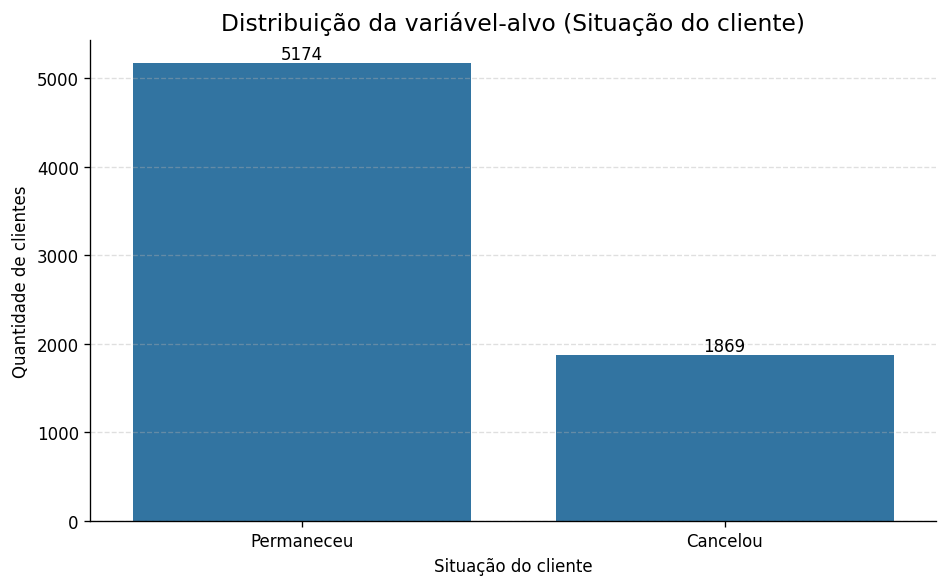

In [677]:
# ============================================================
# Distribuição da variável-alvo (Churn)
# Exibe graficamente a quantidade de clientes que permaneceram
# ou cancelaram o serviço.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

ax = sns.countplot(
    data=df,
    x="Churn",
    order=["No", "Yes"]
)

# Traduz os rótulos do eixo X apenas para apresentação.
ax.set_xticklabels(
    [
        TARGET_LABELS[label.get_text()]
        for label in ax.get_xticklabels()
    ]
)

plt.title(
    f"Distribuição da variável-alvo ({COLUMN_LABELS['Churn']})",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["Churn"])
plt.ylabel("Quantidade de clientes")

# Aplica a padronização visual dos gráficos de barras.
format_countplot(ax)

plt.show()

### Principais observações

A distribuição da variável-alvo mostra que **73,46%** dos clientes permaneceram na empresa, enquanto **26,54%** cancelaram o serviço. Isso indica a presença de um **desbalanceamento moderado** entre as classes, com predominância de clientes que não realizaram o cancelamento.

Embora esse desbalanceamento não seja extremo, ele deve ser considerado durante a avaliação dos modelos. Caso fosse utilizada apenas a acurácia (*accuracy*), um modelo poderia obter um bom resultado simplesmente prevendo que todos os clientes permaneceriam na empresa, sem identificar corretamente aqueles que realmente cancelaram o serviço.

Por esse motivo, a principal métrica de avaliação deste projeto será o **F1-score**, que considera simultaneamente a **precisão (precision)** e a **revocação (recall)**, proporcionando uma avaliação mais equilibrada do desempenho do modelo diante do desbalanceamento observado.

Neste momento, a distribuição das classes não indica, por si só, a necessidade de aplicar técnicas de balanceamento dos dados. Essa decisão será reavaliada após o treinamento dos primeiros modelos, considerando os resultados obtidos na etapa de modelagem.

## 4.2 Análise das variáveis numéricas

As variáveis numéricas representam informações quantitativas sobre os clientes e podem exercer influência importante na previsão do cancelamento do serviço.

Nesta etapa será analisada a distribuição dessas variáveis, buscando identificar possíveis assimetrias, diferenças de escala, concentrações de valores e indícios da presença de valores extremos (*outliers*). Essas características poderão influenciar as estratégias de preparação dos dados e o desempenho dos modelos de Machine Learning.

In [678]:
# ============================================================
# Variáveis numéricas
# Identifica os atributos numéricos que serão utilizados na
# análise exploratória. A variável "SeniorCitizen" é tratada
# como categórica, apesar de estar armazenada como numérica.
# ============================================================

numeric_columns = (
    df.select_dtypes(include=["int64", "float64"])
      .columns
      .drop("SeniorCitizen")
      .tolist()
)

print("Variáveis numéricas identificadas:")

for column in numeric_columns:
    print(f"- {COLUMN_LABELS[column]}")

Variáveis numéricas identificadas:
- Tempo de permanência (meses)
- Valor mensal (R$)


In [679]:
# ============================================================
# Estatísticas descritivas
# Apresenta medidas estatísticas das variáveis numéricas,
# permitindo compreender sua distribuição, dispersão e
# amplitude dos valores.
# ============================================================

descriptive_statistics = (
    df[numeric_columns]
    .describe()
    .T
    .rename(index=COLUMN_LABELS)
    .rename(
        columns={
            "count": "Quantidade",
            "mean": "Média",
            "std": "Desvio padrão",
            "min": "Mínimo",
            "25%": "1º quartil",
            "50%": "Mediana",
            "75%": "3º quartil",
            "max": "Máximo"
        }
    )
)

display(descriptive_statistics)

,Quantidade,Média,Desvio padrão,Mínimo,1º quartil,Mediana,3º quartil,Máximo
Tempo de permanência (meses),7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
Valor mensal (R$),7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### 4.2.1 Tempo de permanência do cliente

Nesta etapa é analisada a variável **Tempo de permanência (tenure)**, que representa o número de meses em que cada cliente permaneceu utilizando os serviços da empresa.

O objetivo é compreender como essa variável está distribuída entre os clientes e verificar a existência de padrões, assimetrias ou valores extremos que possam influenciar a etapa de modelagem.

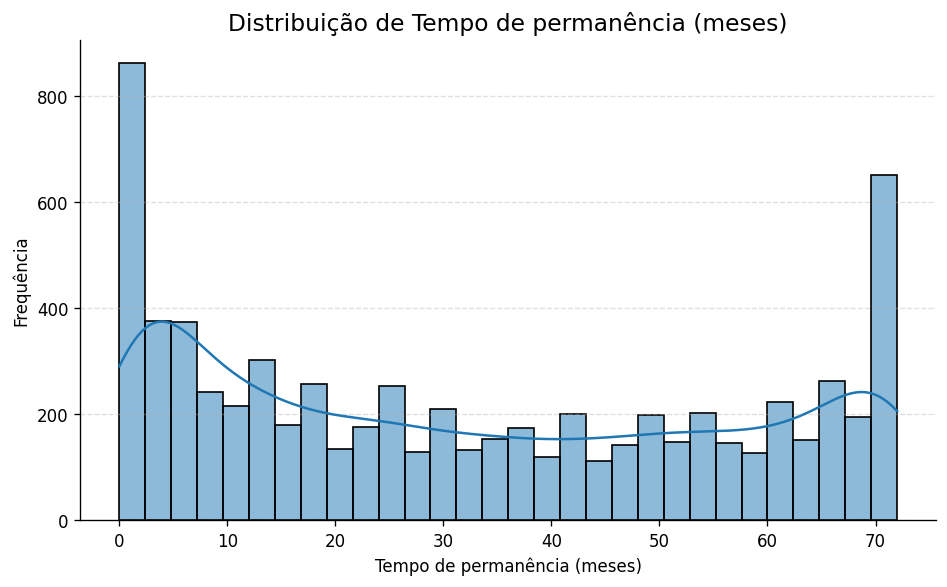

In [680]:
# ============================================================
# Distribuição da variável "Tempo de permanência"
# ============================================================

plt.figure(figsize=(8,5), dpi=120)

sns.histplot(
    data=df,
    x="tenure",
    bins=30,
    kde=True
)

plt.title(f"Distribuição de {COLUMN_LABELS['tenure']}", fontsize=14)
plt.xlabel(COLUMN_LABELS["tenure"])
plt.ylabel("Frequência")

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

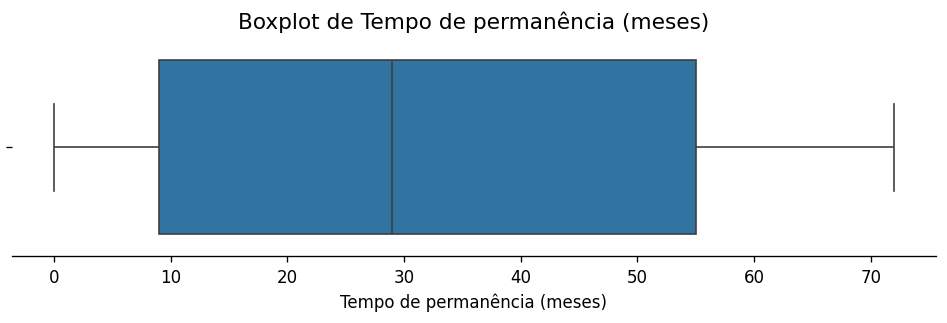

In [681]:
# ============================================================
# Boxplot da variável "Tempo de permanência"
# ============================================================

plt.figure(figsize=(8,2.8), dpi=120)

sns.boxplot(
    data=df,
    x="tenure"
)

plt.title(f"Boxplot de {COLUMN_LABELS['tenure']}", fontsize=13)
plt.xlabel(COLUMN_LABELS["tenure"])

sns.despine(left=True)

plt.tight_layout()
plt.show()

### Principais observações

**Fatos observados**

- A variável apresenta valores entre **0 e 72 meses**, indicando a presença de clientes recém-adquiridos e clientes com longo tempo de relacionamento com a empresa.
- O histograma mostra maior concentração de clientes nos extremos da distribuição, especialmente entre clientes com poucos meses de permanência e clientes com aproximadamente 72 meses de relacionamento.
- O boxplot não evidencia valores extremos (*outliers*) relevantes, indicando que a distribuição da variável é consistente para utilização nos modelos de Machine Learning.

**Hipóteses levantadas**

- O tempo de permanência do cliente pode estar relacionado ao cancelamento do serviço. Essa hipótese será investigada posteriormente ao analisar a relação entre essa variável e a variável-alvo (**Churn**).

### 4.2.2 Valor mensal pago pelo cliente

Nesta etapa é analisada a variável **Valor mensal (MonthlyCharges)**, que representa o valor cobrado mensalmente de cada cliente pelos serviços contratados.

O objetivo é compreender a distribuição dos valores cobrados, verificar sua dispersão e identificar possíveis padrões que possam estar relacionados ao comportamento dos clientes.

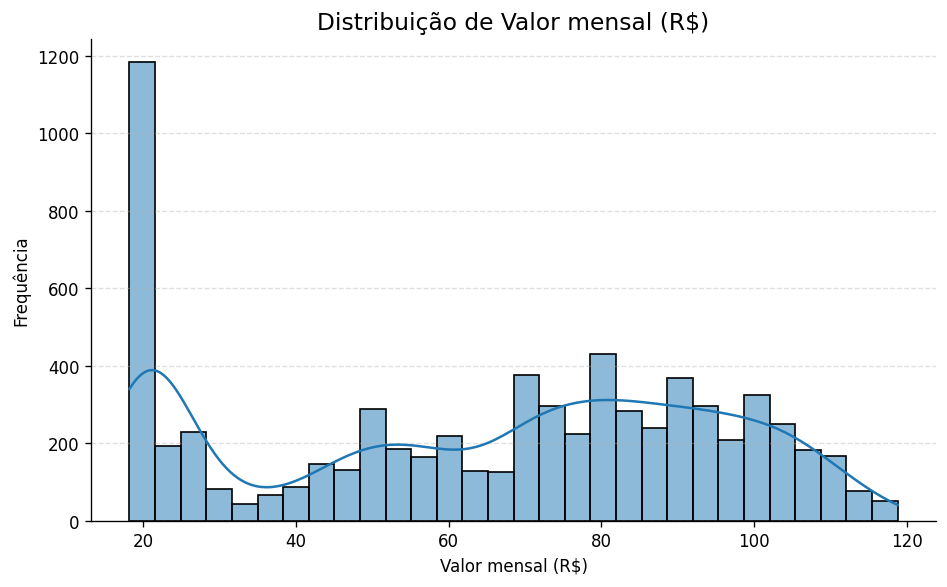

In [682]:
# ============================================================
# Distribuição da variável "Valor mensal"
# Exibe a distribuição dos valores mensais pagos pelos
# clientes.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True
)

plt.title(
    f"Distribuição de {COLUMN_LABELS['MonthlyCharges']}",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["MonthlyCharges"])
plt.ylabel("Frequência")

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

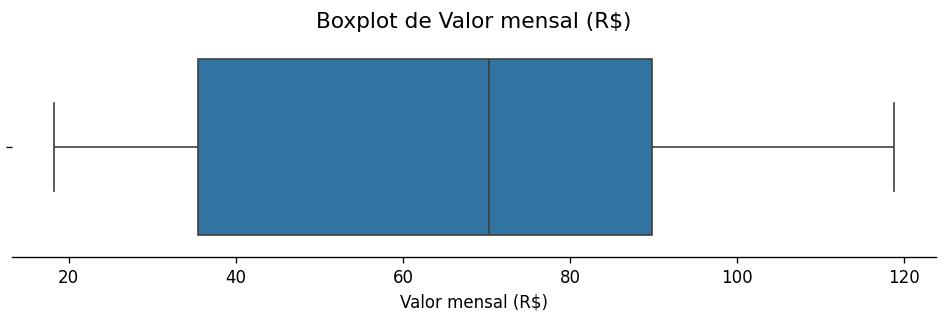

In [683]:
# ============================================================
# Distribuição e identificação de possíveis outliers
# Exibe o boxplot da variável "Valor mensal", permitindo
# visualizar sua dispersão e possíveis valores extremos.
# ============================================================

plt.figure(figsize=(8, 2.8), dpi=120)

sns.boxplot(
    data=df,
    x="MonthlyCharges"
)

plt.title(
    f"Boxplot de {COLUMN_LABELS['MonthlyCharges']}",
    fontsize=13
)

plt.xlabel(COLUMN_LABELS["MonthlyCharges"])

sns.despine(left=True)

plt.tight_layout()
plt.show()

### Principais observações

**Fatos observados**

- A variável apresenta valores entre **18,25** e **118,75**, demonstrando uma ampla variação nos valores mensais pagos pelos clientes.
- O histograma indica que os valores estão distribuídos em diferentes faixas de cobrança, sem concentração excessiva em um único intervalo.
- O boxplot não evidencia valores extremos (*outliers*) relevantes, indicando que a variável apresenta comportamento adequado para utilização na etapa de modelagem.

**Hipóteses levantadas**

- O valor mensal pago pelo cliente pode estar relacionado ao cancelamento do serviço. Essa hipótese será investigada posteriormente ao analisar sua relação com a variável-alvo (**Churn**).

## 4.3 Análise das variáveis categóricas

As variáveis categóricas descrevem características dos clientes e dos serviços contratados. Sua análise permite compreender como os clientes estão distribuídos entre as diferentes categorias presentes na base de dados e identificar padrões que poderão ser investigados nas etapas seguintes da análise exploratória.

Inicialmente, será apresentada a distribuição de todas as variáveis categóricas por meio de tabelas de frequência. Em seguida, serão destacadas graficamente apenas as variáveis consideradas mais relevantes para o problema de negócio, permitindo uma análise mais detalhada de características que podem influenciar o cancelamento do serviço.

Ao final desta seção, serão apresentados os principais fatos observados e as hipóteses levantadas a partir da análise, que servirão de base para a etapa de relacionamento entre as variáveis e a variável-alvo (**Churn**).

### 4.3.1 Identificação das variáveis categóricas

Nesta etapa são identificadas as variáveis categóricas presentes no conjunto de dados que serão analisadas ao longo da EDA.

Embora a coluna **SeniorCitizen** esteja armazenada como um valor numérico (`0` e `1`), ela representa uma característica categórica binária e, por esse motivo, também será considerada nas análises envolvendo variáveis categóricas.

A coluna **customerID** não será utilizada nas análises por representar apenas um identificador único de cada cliente. Já a variável **Churn** corresponde à variável-alvo do problema e será analisada separadamente.

In [684]:
# ============================================================
# Variáveis categóricas
# Identifica os atributos categóricos que serão utilizados
# na análise exploratória. A variável "SeniorCitizen",
# embora armazenada como numérica, também é considerada
# categórica por representar uma característica binária.
# ============================================================

categorical_columns = (
    df.select_dtypes(include="object")
      .columns
      .drop([
          "customerID",
          "Churn",
          "TotalCharges"
      ])
      .tolist()
)

# Inclui a variável SeniorCitizen na lista de variáveis categóricas
categorical_columns.insert(0, "SeniorCitizen")

print("Variáveis categóricas identificadas:\n")

for column in categorical_columns:
    print(f"• {COLUMN_LABELS[column]}")

Variáveis categóricas identificadas:

• Cliente idoso
• Gênero
• Possui parceiro(a)
• Possui dependentes
• Serviço telefônico
• Múltiplas linhas
• Serviço de internet
• Segurança online
• Backup online
• Proteção do dispositivo
• Suporte técnico
• Streaming de TV
• Streaming de filmes
• Tipo de contrato
• Cobrança sem papel
• Método de pagamento


### 4.3.2 Distribuição das categorias

Nesta etapa é apresentada a frequência absoluta e relativa das categorias presentes em cada variável categórica.

Essa análise permite identificar categorias predominantes, categorias pouco representadas e possíveis inconsistências nos dados antes da etapa de modelagem.

In [685]:
# ============================================================
# Frequência das categorias
# Apresenta a quantidade e o percentual de cada categoria
# das variáveis categóricas identificadas.
# ============================================================

for column in categorical_columns:

    print(f"\n{'=' * 80}")
    print(COLUMN_LABELS[column])
    print(f"{'=' * 80}")

    frequency = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis("Categoria")
        .reset_index(name="Quantidade")
    )

    # Traduz as categorias apenas para apresentação
    frequency["Categoria"] = (
        frequency["Categoria"]
        .replace(CATEGORY_LABELS)
    )

    frequency["Percentual (%)"] = (
        frequency["Quantidade"]
        / frequency["Quantidade"].sum()
        * 100
    ).round(2)

    display(frequency)


Cliente idoso


,Categoria,Quantidade,Percentual (%)
0,Não,5901,83.79
1,Sim,1142,16.21



Gênero


,Categoria,Quantidade,Percentual (%)
0,Masculino,3555,50.48
1,Feminino,3488,49.52



Possui parceiro(a)


...

,Categoria,Quantidade,Percentual (%)
0,Mensal,3875,55.02
1,2 anos,1695,24.07
2,1 ano,1473,20.91



Cobrança sem papel


,Categoria,Quantidade,Percentual (%)
0,Sim,4171,59.22
1,Não,2872,40.78



Método de pagamento


,Categoria,Quantidade,Percentual (%)
0,Cheque eletrônico,2365,33.58
1,Cheque enviado,1612,22.89
2,Transferência bancária (automática),1544,21.92
3,Cartão de crédito (automático),1522,21.61


### 4.3.3 Tipo de contrato

Nesta etapa é analisada a variável **Tipo de contrato**, que representa a modalidade contratada por cada cliente.

Os clientes podem possuir contratos mensais, anuais ou de dois anos. A distribuição dessa variável é importante porque diferentes tipos de contrato podem estar associados a diferentes comportamentos de permanência e fidelização dos clientes.

Neste momento, o objetivo é compreender apenas como os clientes estão distribuídos entre as modalidades existentes. A relação entre o tipo de contrato e o cancelamento do serviço será investigada posteriormente na análise conjunta com a variável-alvo (**Churn**).

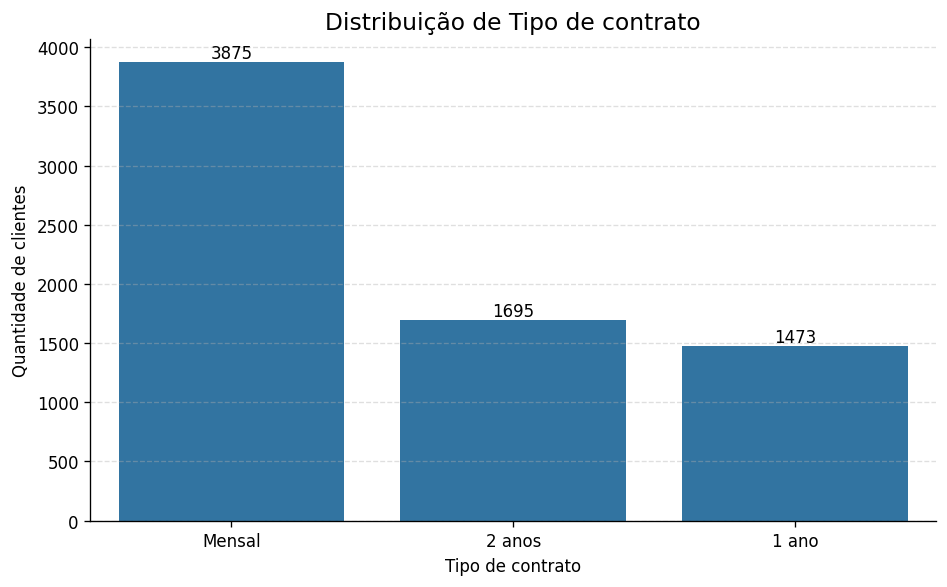

In [686]:
# ============================================================
# Distribuição do tipo de contrato
# Exibe a quantidade de clientes em cada modalidade de
# contrato presente no conjunto de dados.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

ax = sns.countplot(
    data=df,
    x="Contract",
    order=df["Contract"].value_counts().index
)

# Traduz os rótulos apenas para apresentação.
ax.set_xticklabels(
    [
        CATEGORY_LABELS[label.get_text()]
        for label in ax.get_xticklabels()
    ]
)

plt.title(
    f"Distribuição de {COLUMN_LABELS['Contract']}",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["Contract"])
plt.ylabel("Quantidade de clientes")

format_countplot(ax)

plt.show()

### Principais observações

**Fatos observados**

- O tipo de contrato mais frequente é o **Mensal**, representando aproximadamente **55%** dos clientes da base.
- Os contratos de **1 ano** e **2 anos** apresentam participação menor e relativamente semelhante quando comparados ao contrato mensal.
- A distribuição demonstra que mais da metade dos clientes não possui contratos de longo prazo.

**Hipóteses levantadas**

- Clientes com contratos mensais podem apresentar maior probabilidade de cancelar o serviço quando comparados aos clientes que possuem contratos de longo prazo.
- Essa hipótese será verificada posteriormente ao analisar a relação entre o **Tipo de contrato** e a variável-alvo (**Churn**).

### 4.3.4 Serviço de internet

Nesta etapa é analisada a variável **Serviço de internet**, que representa a tecnologia de conexão utilizada por cada cliente.

Os clientes podem contratar o serviço de internet por **Fibra óptica**, **DSL** ou optar por não contratar esse serviço. Compreender a distribuição dessas categorias é importante para caracterizar o perfil da base de clientes e levantar possíveis hipóteses sobre diferenças de comportamento entre os grupos.

Neste momento, o objetivo é apenas analisar como os clientes estão distribuídos entre as modalidades de serviço. A relação entre o tipo de serviço contratado e o cancelamento do serviço será investigada posteriormente na análise conjunta com a variável-alvo (**Churn**).

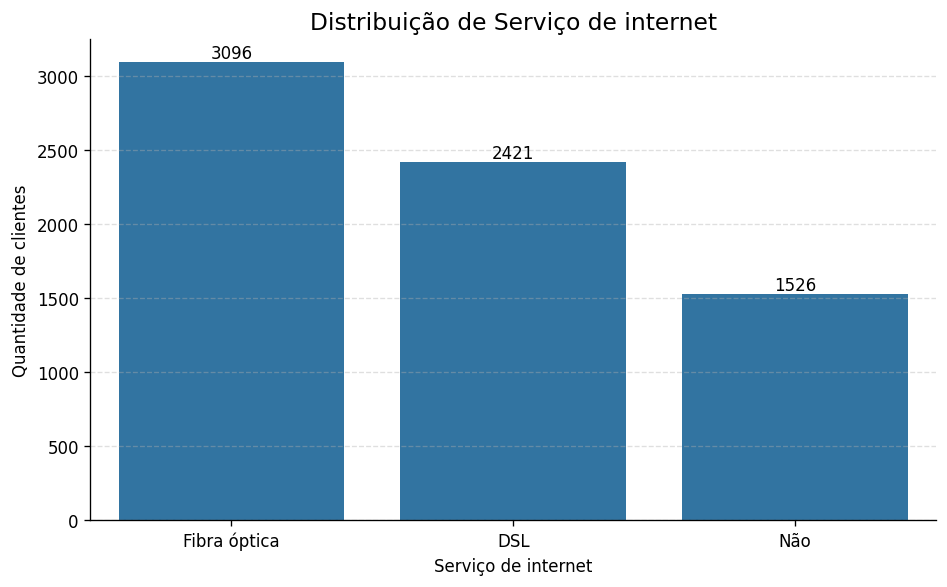

In [687]:
# ============================================================
# Distribuição do serviço de internet
# Exibe a quantidade de clientes conforme o tipo de
# serviço de internet contratado.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

ax = sns.countplot(
    data=df,
    x="InternetService",
    order=df["InternetService"].value_counts().index
)

# Traduz os rótulos apenas para apresentação.
ax.set_xticklabels(
    [
        CATEGORY_LABELS[label.get_text()]
        for label in ax.get_xticklabels()
    ]
)

plt.title(
    f"Distribuição de {COLUMN_LABELS['InternetService']}",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["InternetService"])
plt.ylabel("Quantidade de clientes")

format_countplot(ax)

plt.show()

### Principais observações

**Fatos observados**

- A modalidade **Fibra óptica** é a mais utilizada pelos clientes, representando aproximadamente **44%** da base de dados.
- O serviço **DSL** também possui participação significativa, correspondendo a cerca de **34%** dos clientes.
- Aproximadamente **22%** dos clientes não possuem serviço de internet contratado, indicando que parte da base utiliza apenas outros serviços oferecidos pela empresa.

**Hipóteses levantadas**

- O tipo de serviço de internet contratado pode estar associado ao comportamento dos clientes e influenciar a probabilidade de cancelamento do serviço.
- Essa hipótese será investigada posteriormente ao analisar a relação entre o **Serviço de internet** e a variável-alvo (**Churn**).

### 4.3.5 Método de pagamento

Nesta etapa é analisada a variável **Método de pagamento**, que representa a forma utilizada pelos clientes para realizar o pagamento dos serviços contratados.

Os clientes podem realizar os pagamentos por **Cheque eletrônico**, **Cheque enviado**, **Transferência bancária automática** ou **Cartão de crédito automático**. A análise dessa variável permite compreender quais métodos são mais utilizados pelos clientes e levantar hipóteses sobre possíveis diferenças de comportamento entre os grupos.

Neste momento, o objetivo é apenas analisar a distribuição dos métodos de pagamento presentes na base de dados. A relação entre o método de pagamento e o cancelamento do serviço será investigada posteriormente na análise conjunta com a variável-alvo (**Churn**).

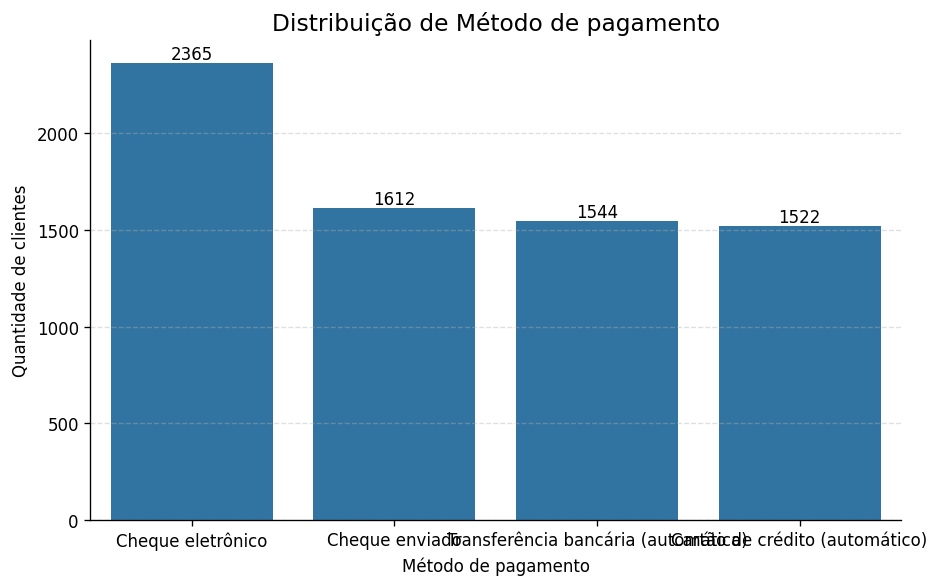

In [688]:
# ============================================================
# Distribuição do método de pagamento
# Exibe a quantidade de clientes conforme o método de
# pagamento utilizado.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

ax = sns.countplot(
    data=df,
    x="PaymentMethod",
    order=df["PaymentMethod"].value_counts().index
)

# Traduz os rótulos apenas para apresentação.
ax.set_xticklabels(
    [
        CATEGORY_LABELS[label.get_text()]
        for label in ax.get_xticklabels()
    ]
)

plt.title(
    f"Distribuição de {COLUMN_LABELS['PaymentMethod']}",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["PaymentMethod"])
plt.ylabel("Quantidade de clientes")

format_countplot(ax)

plt.show()

### Principais observações

**Fatos observados**

- O **Cheque eletrônico** é o método de pagamento mais utilizado, representando aproximadamente **34%** dos clientes.
- Os demais métodos de pagamento apresentam distribuições bastante semelhantes, com participação próxima de **22%** cada.
- A distribuição indica que, embora exista um método predominante, a base de clientes utiliza diferentes formas de pagamento de maneira relativamente equilibrada.

**Hipóteses levantadas**

- O método de pagamento utilizado pode estar associado ao comportamento dos clientes e influenciar a probabilidade de cancelamento do serviço.
- Essa hipótese será investigada posteriormente ao analisar a relação entre o **Método de pagamento** e a variável-alvo (**Churn**).

### 4.3.6 Cobrança sem papel

Nesta etapa é analisada a variável **Cobrança sem papel**, que indica se o cliente optou por receber suas cobranças em formato digital, dispensando o envio de documentos impressos.

Essa característica permite compreender o perfil dos clientes em relação à forma de recebimento das faturas e pode refletir diferenças de comportamento ou preferência pelo uso de serviços digitais.

Neste momento, o objetivo é apenas analisar a distribuição dessa característica na base de dados. A influência dessa opção sobre o cancelamento do serviço será investigada posteriormente na análise conjunta com a variável-alvo (**Churn**).

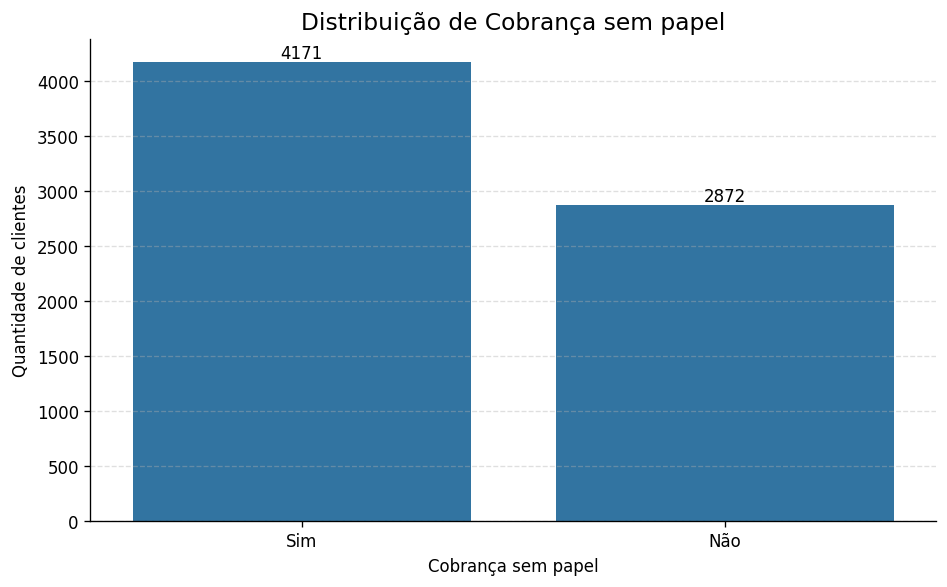

In [689]:
# ============================================================
# Distribuição da cobrança sem papel
# Exibe a quantidade de clientes que utilizam ou não
# a modalidade de cobrança digital.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

ax = sns.countplot(
    data=df,
    x="PaperlessBilling",
    order=df["PaperlessBilling"].value_counts().index
)

# Traduz os rótulos apenas para apresentação.
ax.set_xticklabels(
    [
        CATEGORY_LABELS[label.get_text()]
        for label in ax.get_xticklabels()
    ]
)

plt.title(
    f"Distribuição de {COLUMN_LABELS['PaperlessBilling']}",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["PaperlessBilling"])
plt.ylabel("Quantidade de clientes")

format_countplot(ax)

plt.show()

### Principais observações

**Fatos observados**

- Aproximadamente **59%** dos clientes utilizam a modalidade de **cobrança sem papel**, enquanto cerca de **41%** ainda recebem suas cobranças por meios tradicionais.
- A distribuição indica uma predominância da cobrança digital, embora uma parcela significativa dos clientes continue utilizando o modelo convencional.

**Hipóteses levantadas**

- A preferência pela cobrança digital pode estar relacionada ao perfil de utilização dos serviços e, consequentemente, apresentar comportamentos distintos em relação ao cancelamento.
- Essa possibilidade será analisada posteriormente ao relacionar a variável **Cobrança sem papel** com a variável-alvo (**Churn**).

### 4.3.7 Síntese da análise das variáveis categóricas

A análise das variáveis categóricas permitiu compreender melhor o perfil dos clientes e a distribuição das principais características presentes no conjunto de dados.

Observou-se que a maioria dos clientes possui **contrato mensal**, utiliza **serviço de internet por fibra óptica**, realiza os pagamentos por **cheque eletrônico** e opta pela **cobrança sem papel**.

Embora essas distribuições revelem características importantes da base de dados, elas não permitem concluir, isoladamente, quais fatores estão associados ao cancelamento do serviço. Nesta etapa foram levantadas hipóteses com base nas distribuições observadas, que deverão ser verificadas por meio da análise conjunta entre cada variável e a variável-alvo (**Churn**).

A próxima seção investigará essas relações, permitindo identificar quais características apresentam maior associação com o cancelamento dos clientes e fornecendo informações importantes para a etapa de modelagem.

## 4.4 Relação entre as variáveis e a variável-alvo

Até este momento, as variáveis do conjunto de dados foram analisadas individualmente, permitindo compreender suas distribuições, características e possíveis padrões presentes na base de clientes.

Embora essa análise seja importante para conhecer o comportamento de cada variável, ela não é suficiente para identificar quais características estão efetivamente relacionadas ao cancelamento do serviço.

Nesta etapa, cada variável será analisada em conjunto com a variável-alvo (**Churn**), buscando verificar se existem diferenças entre os clientes que permaneceram e aqueles que cancelaram o serviço.

O objetivo é identificar possíveis associações entre as características dos clientes e o cancelamento, levantando evidências que possam contribuir para a seleção das variáveis, para a preparação dos dados e para a interpretação dos modelos de Machine Learning desenvolvidos nas próximas etapas.

É importante destacar que essa análise permite identificar associações observadas nos dados, mas não estabelece relações de causa e efeito. As conclusões obtidas servirão como suporte para a construção e avaliação dos modelos preditivos.

### Estratégia de visualização

Nesta etapa são utilizados diferentes tipos de gráficos de acordo com a natureza das variáveis analisadas.

Para as **variáveis numéricas**, serão utilizados **boxplots**, pois permitem comparar a distribuição dos valores entre os clientes que permaneceram e aqueles que cancelaram o serviço, evidenciando diferenças de mediana, dispersão e possíveis valores extremos.

Para as **variáveis categóricas**, serão utilizados **gráficos de barras empilhadas em percentual (100%)**, que permitem comparar a proporção de clientes que permaneceram e cancelaram dentro de cada categoria. Esse tipo de visualização facilita a identificação de possíveis associações entre as categorias das variáveis e a variável-alvo (**Churn**), independentemente da quantidade de registros existente em cada grupo.

### 4.4.1 Tempo de permanência × Cancelamento do serviço

Nesta etapa é analisada a relação entre o **Tempo de permanência do cliente** e a variável-alvo (**Churn**).

O tempo de permanência representa a quantidade de meses em que cada cliente permaneceu utilizando os serviços da empresa. Comparar essa variável entre clientes que permaneceram e aqueles que cancelaram o serviço permite verificar se existem diferenças relevantes entre os dois grupos.

Como se trata de uma variável numérica, será utilizado um **boxplot**, que permite comparar a distribuição dos valores entre as classes da variável-alvo, evidenciando diferenças de mediana, dispersão, quartis e possíveis valores extremos.

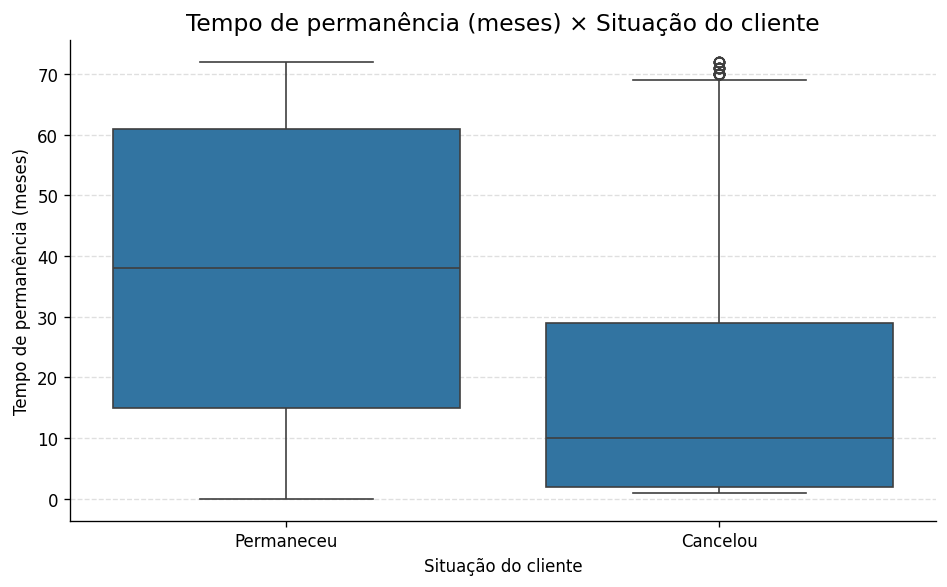

In [690]:
# ============================================================
# Tempo de permanência × Churn
# Compara a distribuição do tempo de permanência entre os
# clientes que permaneceram e aqueles que cancelaram
# o serviço.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="tenure",
    order=["No", "Yes"]
)

# Traduz os rótulos da variável-alvo.
ax.set_xticklabels(
    [
        TARGET_LABELS[label.get_text()]
        for label in ax.get_xticklabels()
    ]
)

plt.title(
    f"{COLUMN_LABELS['tenure']} × {COLUMN_LABELS['Churn']}",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["Churn"])
plt.ylabel(COLUMN_LABELS["tenure"])

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

### Principais observações

**Fatos observados**

- Os clientes que **cancelaram o serviço** apresentam, em geral, um **tempo de permanência significativamente menor** do que os clientes que permaneceram na empresa.
- A mediana do tempo de permanência é substancialmente superior entre os clientes que permaneceram, indicando que esse grupo tende a manter um relacionamento mais longo com a empresa.
- Também é possível observar que a maior concentração de clientes que cancelaram está nos primeiros meses de contrato, embora existam alguns casos isolados de cancelamento após longos períodos de permanência.

**Interpretação**

A distribuição observada evidencia uma associação entre o **Tempo de permanência** e a variável-alvo (**Churn**). Os resultados sugerem que clientes com menor tempo de relacionamento apresentam maior ocorrência de cancelamento, enquanto clientes com maior tempo de permanência tendem a permanecer na empresa.

Embora essa análise não permita estabelecer uma relação de causa e efeito, ela indica que o **Tempo de permanência** possui potencial para contribuir significativamente com a capacidade preditiva dos modelos de Machine Learning e deverá ser considerado na etapa de modelagem.

### 4.4.2 Valor mensal × Cancelamento do serviço

Nesta etapa é analisada a relação entre o **Valor mensal** pago pelos clientes e a variável-alvo (**Churn**).

O valor mensal representa o custo dos serviços contratados por cada cliente. Comparar essa variável entre os clientes que permaneceram e aqueles que cancelaram o serviço permite verificar se existem diferenças nos valores pagos pelos dois grupos.

Como se trata de uma variável numérica, será utilizado um **boxplot**, que permite comparar a distribuição dos valores entre as classes da variável-alvo, evidenciando diferenças de mediana, dispersão, quartis e possíveis valores extremos.

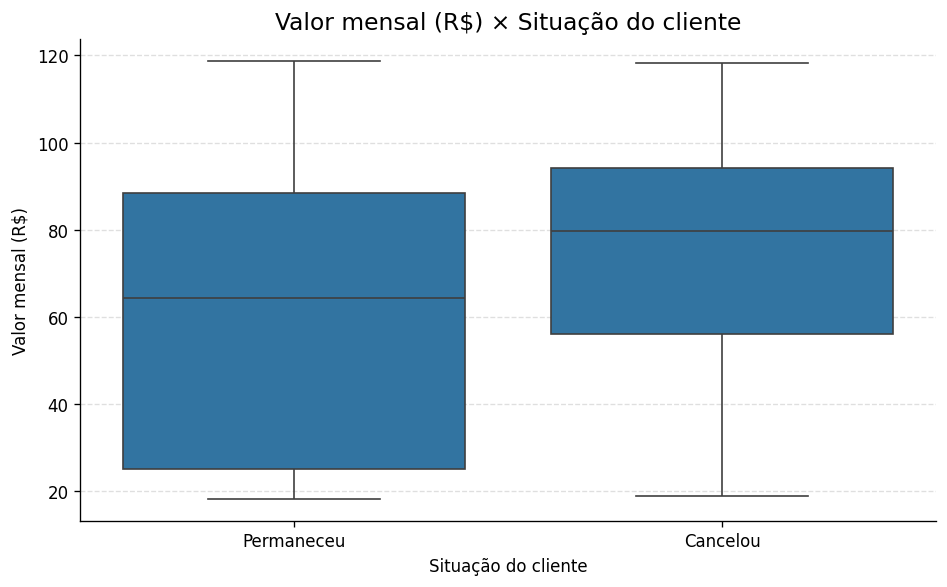

In [691]:
# ============================================================
# Valor mensal × Churn
# Compara a distribuição do valor mensal entre os clientes
# que permaneceram e aqueles que cancelaram o serviço.
# ============================================================

plt.figure(figsize=(8, 5), dpi=120)

ax = sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    order=["No", "Yes"]
)

# Traduz os rótulos da variável-alvo.
ax.set_xticklabels(
    [
        TARGET_LABELS[label.get_text()]
        for label in ax.get_xticklabels()
    ]
)

plt.title(
    f"{COLUMN_LABELS['MonthlyCharges']} × {COLUMN_LABELS['Churn']}",
    fontsize=14
)

plt.xlabel(COLUMN_LABELS["Churn"])
plt.ylabel(COLUMN_LABELS["MonthlyCharges"])

plt.grid(axis="y", linestyle="--", alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

### Principais observações

**Fatos observados**

- Os clientes que **cancelaram o serviço** apresentam, em geral, **valores mensais mais elevados** do que aqueles que permaneceram na empresa.
- A mediana do valor mensal é superior entre os clientes que cancelaram, indicando uma diferença consistente entre os dois grupos.
- Também é possível observar que os clientes que permaneceram apresentam uma distribuição mais ampla dos valores mensais, abrangendo desde planos de menor custo até planos com mensalidades mais elevadas.

**Interpretação**

Os resultados sugerem que o **Valor mensal** está associado ao comportamento de cancelamento observado na base de dados. Clientes com mensalidades mais elevadas tendem a apresentar maior ocorrência de cancelamento quando comparados aos clientes que pagam valores mensais menores.

Apesar dessa associação, a análise não permite afirmar que o valor da mensalidade seja a causa do cancelamento. Outros fatores podem influenciar esse comportamento e serão analisados nas próximas etapas. Ainda assim, a diferença observada indica que essa variável possui potencial para contribuir com o desempenho dos modelos preditivos.

### 4.4.3 Tipo de contrato × Cancelamento do serviço

Nesta etapa é analisada a relação entre o **Tipo de contrato** e a variável-alvo (**Churn**).

O tipo de contrato representa a modalidade escolhida pelo cliente para a prestação do serviço, podendo ser **Mensal**, **1 ano** ou **2 anos**. Comparar essa variável com a situação do cliente permite verificar se determinadas modalidades apresentam proporções diferentes de cancelamento.

Como se trata de uma variável categórica, será utilizado um **gráfico de barras empilhadas em percentual (100%)**, que permite comparar a proporção de clientes que permaneceram e cancelaram dentro de cada categoria, independentemente da quantidade de clientes existente em cada grupo.

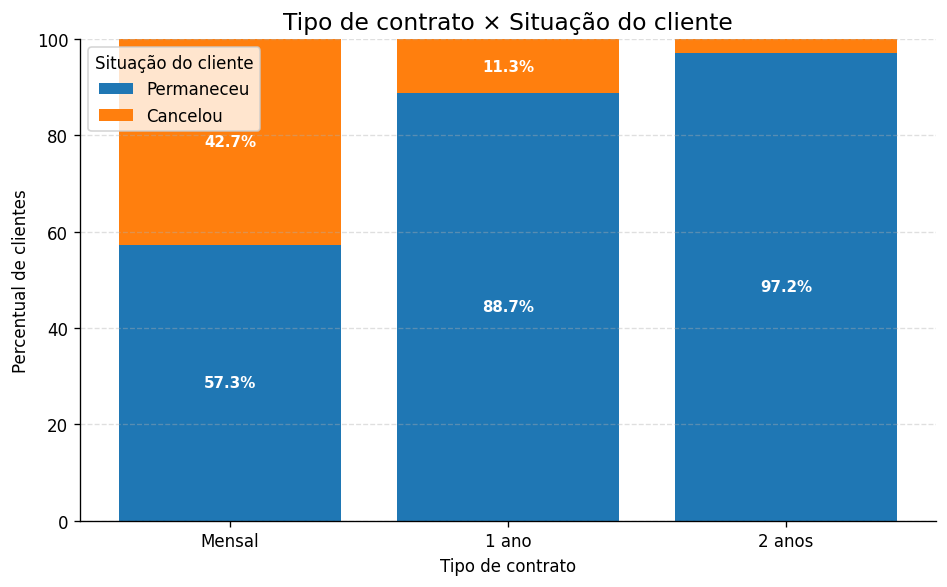

In [692]:
# ============================================================
# Tipo de contrato × Churn
# Compara a proporção de clientes que permaneceram e
# cancelaram em cada modalidade de contrato.
# ============================================================

plot_stacked_percentage(
    df,
    feature="Contract",
    target="Churn"
)

### Principais observações

**Fatos observados**

- Os clientes com **contrato mensal** apresentam a maior proporção de cancelamento, com aproximadamente **42,7%** dos clientes encerrando o serviço.
- Entre os clientes com **contrato de 1 ano**, a taxa de cancelamento é significativamente menor, correspondendo a cerca de **11,3%**.
- Os clientes com **contrato de 2 anos** apresentam a menor proporção de cancelamento, com apenas **2,8%**, indicando elevada permanência na empresa.

**Interpretação**

A análise evidencia uma forte associação entre o **Tipo de contrato** e a variável-alvo (**Churn**). Observa-se uma redução expressiva na proporção de cancelamentos à medida que aumenta a duração do contrato.

Embora essa relação não permita estabelecer causalidade, os resultados sugerem que clientes vinculados a contratos de maior duração tendem a permanecer por mais tempo na empresa. Dessa forma, o **Tipo de contrato** demonstra elevado potencial para contribuir com o desempenho dos modelos preditivos e deverá ser mantido durante a etapa de modelagem.

### 4.4.4 Serviço de internet × Cancelamento do serviço

Nesta etapa é analisada a relação entre o **Serviço de internet** contratado pelos clientes e a variável-alvo (**Churn**).

Os clientes podem contratar o serviço de internet por **Fibra óptica**, **DSL** ou não contratar esse serviço. Comparar essas categorias com a situação do cliente permite verificar se existem diferenças na proporção de cancelamento entre as modalidades disponíveis.

Como se trata de uma variável categórica, será utilizado um **gráfico de barras empilhadas em percentual (100%)**, permitindo comparar a proporção de clientes que permaneceram e cancelaram em cada categoria, independentemente do número de clientes existente em cada grupo.

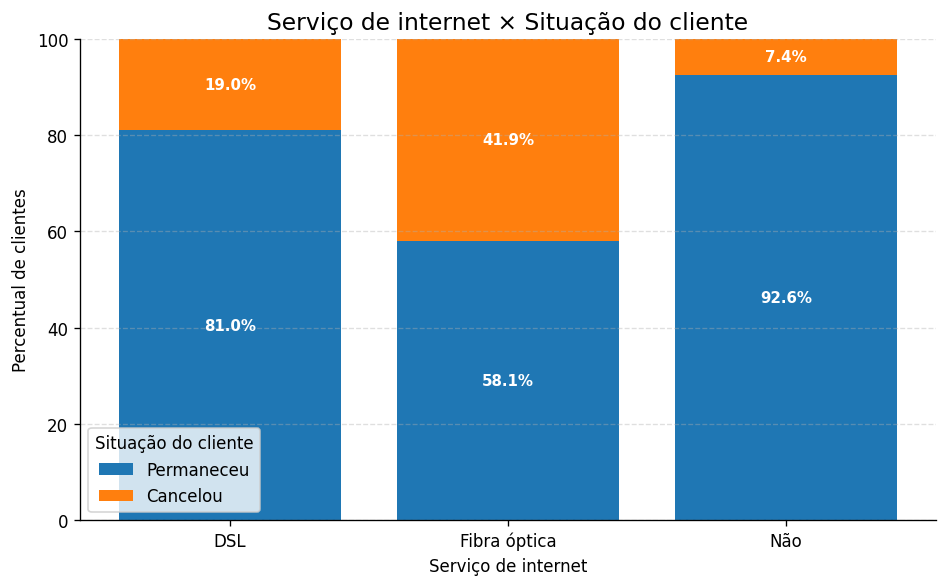

In [693]:
# ============================================================
# Serviço de internet × Churn
# Compara a proporção de clientes que permaneceram e
# cancelaram conforme o tipo de serviço de internet.
# ============================================================

plot_stacked_percentage(
    df,
    feature="InternetService",
    target="Churn"
)

### Principais observações

**Fatos observados**

- Os clientes que utilizam **Fibra óptica** apresentam a maior proporção de cancelamento, com aproximadamente **41,9%** dos clientes encerrando o serviço.
- Entre os clientes que utilizam **DSL**, a taxa de cancelamento é significativamente menor, correspondendo a cerca de **19,0%**.
- Os clientes que **não possuem serviço de internet** apresentam a menor proporção de cancelamento, aproximadamente **7,4%**, indicando elevada permanência na empresa.

**Interpretação**

A análise evidencia uma associação entre o **Serviço de internet** e a variável-alvo (**Churn**). Observa-se que clientes que utilizam **Fibra óptica** apresentam uma proporção de cancelamento consideravelmente superior às demais categorias.

Embora essa análise não permita estabelecer uma relação de causa e efeito, os resultados sugerem que o tipo de serviço contratado pode estar relacionado ao comportamento de cancelamento dos clientes. Essa diferença poderá estar associada a outros fatores presentes na base de dados, como o valor da mensalidade, o tipo de contrato ou o perfil dos clientes, aspectos que serão considerados durante a modelagem.

Dessa forma, o **Serviço de internet** demonstra potencial para contribuir com a capacidade preditiva dos modelos de Machine Learning e deverá ser mantido na etapa de modelagem.

### 4.4.5 Método de pagamento × Cancelamento do serviço

Nesta etapa é analisada a relação entre o **Método de pagamento** utilizado pelos clientes e a variável-alvo (**Churn**).

Os clientes podem realizar seus pagamentos por **Cheque eletrônico**, **Cheque enviado**, **Transferência bancária automática** ou **Cartão de crédito automático**. Comparar essas modalidades com a situação do cliente permite verificar se determinados métodos de pagamento apresentam diferenças na proporção de cancelamento.

Como se trata de uma variável categórica, será utilizado um **gráfico de barras empilhadas em percentual (100%)**, permitindo comparar a proporção de clientes que permaneceram e cancelaram dentro de cada categoria, independentemente da quantidade de clientes existente em cada grupo.

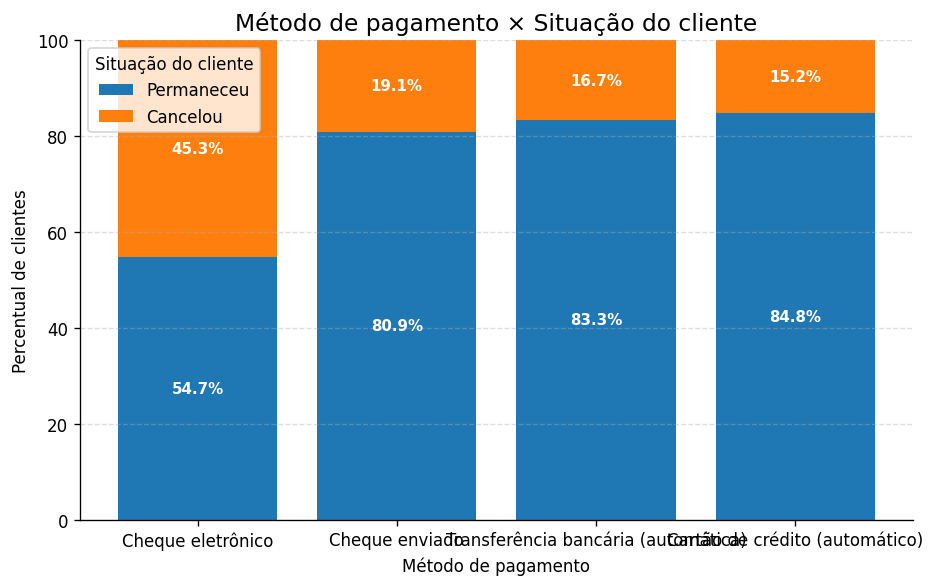

In [694]:
# ============================================================
# Método de pagamento × Churn
# Compara a proporção de clientes que permaneceram e
# cancelaram conforme o método de pagamento utilizado.
# ============================================================

plot_stacked_percentage(
    df,
    feature="PaymentMethod",
    target="Churn"
)

### Principais observações

**Fatos observados**

- Os clientes que utilizam **Cheque eletrônico** apresentam a maior proporção de cancelamento, com aproximadamente **45,3%** dos clientes encerrando o serviço.
- Os demais métodos de pagamento apresentam proporções de cancelamento significativamente menores e bastante semelhantes entre si, variando entre **15,2%** e **19,1%**.
- Entre os métodos analisados, **Cartão de crédito (automático)** apresenta a menor proporção de cancelamento, com aproximadamente **15,2%**.

**Interpretação**

A análise evidencia uma associação entre o **Método de pagamento** e a variável-alvo (**Churn**). Observa-se que clientes que utilizam **Cheque eletrônico** apresentam uma proporção de cancelamento consideravelmente superior à observada nos demais métodos de pagamento.

Embora essa diferença não permita estabelecer uma relação de causa e efeito, os resultados sugerem que o método de pagamento pode estar associado ao perfil dos clientes ou a outras características presentes na base de dados, como o tipo de contrato ou a forma de cobrança.

Dessa forma, o **Método de pagamento** demonstra potencial para contribuir com a capacidade preditiva dos modelos de Machine Learning e deverá ser considerado durante a etapa de modelagem.

### 4.4.6 Cobrança sem papel × Cancelamento do serviço

Nesta etapa é analisada a relação entre a **Cobrança sem papel** e a variável-alvo (**Churn**).

Essa variável indica se o cliente optou por receber suas cobranças em formato digital, dispensando o envio de documentos impressos. Comparar essa característica com a situação do cliente permite verificar se existem diferenças na proporção de cancelamento entre os clientes que utilizam ou não essa modalidade de cobrança.

Como se trata de uma variável categórica, será utilizado um **gráfico de barras empilhadas em percentual (100%)**, permitindo comparar a proporção de clientes que permaneceram e cancelaram dentro de cada categoria, independentemente da quantidade de clientes existente em cada grupo.

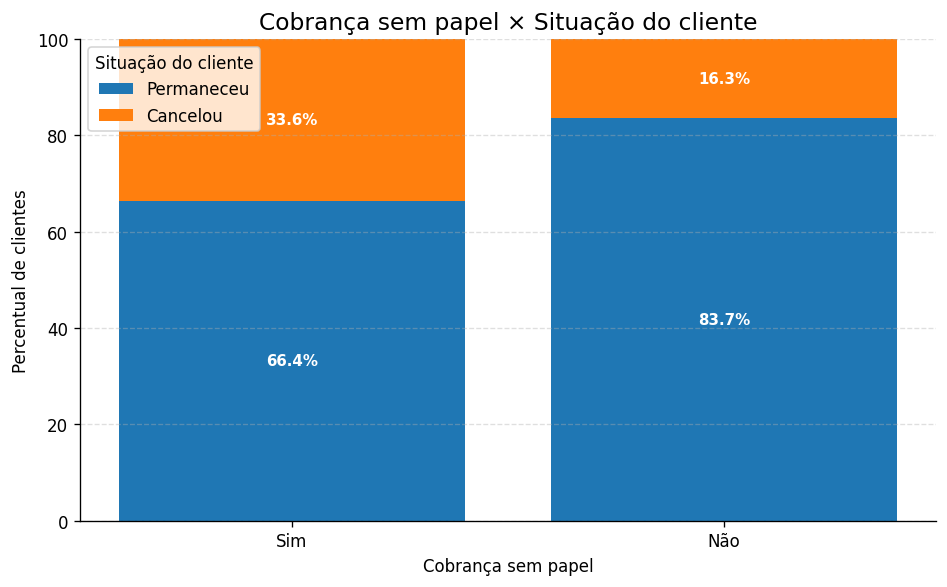

In [695]:
# ============================================================
# Cobrança sem papel × Churn
# Compara a proporção de clientes que permaneceram e
# cancelaram conforme a utilização da cobrança sem papel.
# ============================================================

plot_stacked_percentage(
    df,
    feature="PaperlessBilling",
    target="Churn"
)

### Principais observações

**Fatos observados**

- Os clientes que utilizam **Cobrança sem papel** apresentam uma proporção de cancelamento de aproximadamente **33,6%**, superior à observada entre os clientes que utilizam a cobrança tradicional.
- Entre os clientes que **não utilizam cobrança sem papel**, a taxa de cancelamento corresponde a aproximadamente **16,3%**, indicando maior permanência na empresa.
- Observa-se uma diferença expressiva entre os dois grupos, sugerindo comportamentos distintos em relação ao cancelamento do serviço.

**Interpretação**

A análise evidencia uma associação entre a **Cobrança sem papel** e a variável-alvo (**Churn**). Os resultados sugerem que clientes que optam pela cobrança digital apresentam maior proporção de cancelamento quando comparados aos clientes que utilizam cobranças convencionais.

Entretanto, essa diferença não deve ser interpretada como uma relação de causa e efeito. É possível que essa característica esteja associada a outros fatores presentes na base de dados, como o perfil dos clientes, o método de pagamento ou o tipo de contrato.

Dessa forma, a variável **Cobrança sem papel** demonstra potencial para contribuir com a capacidade preditiva dos modelos de Machine Learning e será mantida durante a etapa de modelagem.

### 4.4.7 Síntese da relação entre as variáveis e a variável-alvo

A análise conjunta das variáveis com a variável-alvo (**Churn**) permitiu identificar diferenças importantes entre os clientes que permaneceram e aqueles que cancelaram o serviço.

Entre as variáveis analisadas, o **Tempo de permanência** e o **Tipo de contrato** apresentaram as associações mais evidentes com o cancelamento, indicando que clientes com menor tempo de relacionamento e contratos mensais tendem a cancelar o serviço com maior frequência.

Também foram observadas diferenças relevantes para as variáveis **Valor mensal**, **Serviço de internet**, **Método de pagamento** e **Cobrança sem papel**, sugerindo que essas características podem contribuir para a capacidade preditiva dos modelos.

Embora as associações identificadas não permitam estabelecer relações de causa e efeito, os resultados obtidos indicam que essas variáveis possuem potencial para explicar parte do comportamento de cancelamento observado na base de dados e, portanto, serão consideradas nas próximas etapas do desenvolvimento do modelo.

## 4.5 Síntese da análise exploratória

A Análise Exploratória dos Dados (EDA) permitiu compreender a estrutura do conjunto de dados, identificar possíveis inconsistências e analisar o comportamento das principais variáveis em relação ao cancelamento do serviço (**Churn**). Os resultados obtidos nesta etapa forneceram informações importantes para orientar as decisões de preparação dos dados e modelagem.

A variável-alvo apresentou **desbalanceamento moderado**, com aproximadamente **73,5%** dos clientes permanecendo na empresa e **26,5%** realizando o cancelamento do serviço. Embora esse nível de desbalanceamento não seja extremo, ele deverá ser considerado durante a avaliação dos modelos, utilizando métricas que complementem a acurácia, como Precisão, Recall, F1-Score e ROC-AUC.

Durante a inspeção inicial dos dados, não foram identificados valores ausentes pelo método `isna()`. Entretanto, foram encontrados **11 registros contendo valores em branco** na variável **TotalCharges**, fazendo com que essa coluna fosse importada como texto (`object`). Como essa variável representa um valor numérico contínuo, ela será convertida para formato numérico e os registros com valores em branco serão tratados durante a etapa de preparação dos dados.

A análise das variáveis numéricas mostrou que o **Tempo de permanência** e o **Valor mensal** apresentam distribuições distintas entre os clientes que permaneceram e aqueles que cancelaram o serviço. Em especial, o tempo de permanência demonstrou uma forte associação com o cancelamento, indicando potencial para contribuir significativamente com os modelos preditivos.

Entre as variáveis categóricas, destacaram-se principalmente o **Tipo de contrato**, o **Serviço de internet**, o **Método de pagamento** e a **Cobrança sem papel**, que apresentaram diferenças relevantes na proporção de cancelamento entre suas categorias. Essas variáveis serão mantidas na modelagem, pois demonstraram potencial para explicar parte do comportamento observado na variável-alvo.

A EDA também permitiu identificar que o conjunto de dados possui variáveis numéricas e categóricas, tornando necessária a aplicação de diferentes técnicas de preparação dos dados. Entre elas destacam-se a conversão da variável **TotalCharges** para formato numérico, o tratamento dos valores em branco, a codificação das variáveis categóricas e a remoção da coluna **customerID**, por representar apenas um identificador dos clientes.

De forma geral, os resultados da análise exploratória indicam que o conjunto de dados apresenta qualidade adequada para o desenvolvimento deste MVP e fornecem evidências de que existem padrões relevantes associados ao cancelamento dos clientes. Essas informações servirão de base para a etapa de preparação dos dados, construção dos modelos de Machine Learning e avaliação do seu desempenho.


# 5. Preparação dos dados e divisão treino/teste

Após a análise exploratória dos dados (EDA), inicia-se a etapa de preparação dos dados para a construção dos modelos de Machine Learning.

Nesta fase serão definidas as variáveis que serão utilizadas durante a modelagem, realizada a separação entre os conjuntos de treinamento e teste e aplicadas as transformações necessárias para que os algoritmos possam aprender padrões presentes nos dados de forma adequada.

Um dos principais objetivos desta etapa é garantir que o processo de treinamento represente um cenário próximo ao encontrado em uma aplicação real. Para isso, todas as transformações que dependem das características dos dados serão ajustadas utilizando apenas o conjunto de treinamento e posteriormente aplicadas ao conjunto de teste, evitando o vazamento de informações (*Data Leakage*).

Ao final desta etapa, os dados estarão organizados e preparados para o treinamento, comparação e avaliação dos modelos de Machine Learning.

In [696]:
# ============================================================
# Configurações globais do experimento
# Centraliza as constantes utilizadas durante as etapas de
# preparação dos dados, treinamento e avaliação dos modelos.
# ============================================================

# Variável-alvo
TARGET = "Churn"

# Proporção do conjunto de teste
TEST_SIZE = 0.20

# Semente para reprodutibilidade
RANDOM_STATE = 42

# Ordem das classes da variável-alvo
TARGET_CLASSES = ["No", "Yes"]

# Métricas utilizadas na avaliação dos modelos
METRIC_COLUMNS = [
    "Acurácia",
    "Precisão",
    "Recall",
    "F1-score"
]

## 5.1 Seleção das variáveis

Antes da construção dos modelos, é necessário definir quais informações serão utilizadas durante o treinamento.

Nesta etapa serão removidos os atributos que não contribuem para a previsão da variável-alvo, definida a variável que representa o problema de classificação e realizada a separação entre as variáveis explicativas (*features*) e a variável de interesse (*target*).

Essa organização facilita as etapas seguintes do fluxo de Machine Learning e evita que informações sem capacidade preditiva sejam utilizadas durante o treinamento dos modelos.

In [697]:
# ============================================================
# Seleção das variáveis
# Remove atributos que não serão utilizados na modelagem,
# define a variável-alvo e separa os dados entre variáveis
# explicativas (X) e variável de interesse (y).
# ============================================================

# Remove o identificador único dos clientes.
df_model = df.drop(columns=["customerID"])

# Define as variáveis explicativas.
X = df_model.drop(columns=["Churn"])

# Define a variável-alvo.
y = df_model["Churn"]

print(f"Quantidade de atributos utilizados: {X.shape[1]}")
print(f"Quantidade de registros: {X.shape[0]}")

print("\nVariável-alvo:")
print(y.name)

Quantidade de atributos utilizados: 19
Quantidade de registros: 7043

Variável-alvo:
Churn


### Principais observações

A coluna **customerID** foi removida por representar apenas um identificador único dos clientes, não contendo informações relevantes para a previsão do cancelamento do serviço.

Após essa remoção, as variáveis foram separadas entre **atributos explicativos (X)** e **variável-alvo (y)**, seguindo a convenção utilizada pela biblioteca **scikit-learn**. Essa organização será utilizada nas próximas etapas de preparação dos dados, treinamento e avaliação dos modelos de Machine Learning.

## 5.2 Tratamento inicial dos dados

Antes da divisão entre os conjuntos de treinamento e teste, é necessário corrigir inconsistências estruturais identificadas durante a Análise Exploratória dos Dados (EDA).

Nesta etapa será realizado o tratamento da variável **TotalCharges**, que foi importada como texto (`object`) devido à presença de registros contendo valores em branco. Como essa variável representa o valor total pago pelo cliente ao longo do relacionamento com a empresa, ela deverá ser convertida para um tipo numérico para que possa ser utilizada pelos algoritmos de Machine Learning.

É importante destacar que essa conversão não utiliza informações estatísticas do conjunto de dados, tratando-se apenas de uma correção no formato da variável. Por esse motivo, essa etapa pode ser realizada antes da divisão entre treinamento e teste, sem risco de vazamento de dados (*Data Leakage*).

As transformações que dependem de informações estatísticas dos dados, como a imputação de valores ausentes, serão realizadas posteriormente, após a divisão entre os conjuntos de treinamento e teste. Dessa forma, essas transformações poderão ser ajustadas utilizando apenas o conjunto de treinamento e, posteriormente, aplicadas ao conjunto de teste, preservando a imparcialidade da avaliação dos modelos.

In [698]:
# ============================================================
# Tratamento inicial dos dados
# Converte a variável TotalCharges para formato numérico,
# transformando valores em branco em valores ausentes (NaN).
# ============================================================

df_model["TotalCharges"] = pd.to_numeric(
    df_model["TotalCharges"],
    errors="coerce"
)

print("Tipo da variável TotalCharges:")
print(df_model["TotalCharges"].dtype)

print("\nValores ausentes em TotalCharges:")
print(df_model["TotalCharges"].isna().sum())

# Recria X após a conversão
X = df_model.drop(columns=["Churn"])

Tipo da variável TotalCharges:
float64

Valores ausentes em TotalCharges:
11


### Principais observações

A variável **TotalCharges** foi convertida com sucesso para o tipo numérico (`float64`), permitindo que essa variável seja tratada como um atributo numérico durante as próximas etapas de pré-processamento e modelagem.

Durante a conversão, os **11 registros contendo valores em branco** foram transformados em valores ausentes (`NaN`). Essa abordagem preserva os registros originais e permite que esses valores sejam tratados posteriormente durante a etapa de pré-processamento.

Como essa transformação consiste apenas na correção do tipo da variável, ela pode ser realizada antes da divisão entre os conjuntos de treinamento e teste sem introduzir risco de vazamento de dados (*Data Leakage*).

Nesta etapa, os valores ausentes **não foram imputados**, pois técnicas de imputação utilizam informações estatísticas do conjunto de dados. Para evitar vazamento de dados, a imputação será realizada posteriormente utilizando apenas o conjunto de treinamento, por meio do pipeline de pré-processamento, sendo posteriormente aplicada ao conjunto de teste.

## 5.3 Divisão entre treino e teste

Após a seleção das variáveis e a correção das inconsistências estruturais identificadas durante a etapa anterior, o conjunto de dados será dividido em dois subconjuntos: **treinamento** e **teste**.

O conjunto de treinamento será utilizado para que os algoritmos aprendam os padrões presentes nos dados. Já o conjunto de teste permanecerá separado durante todo o processo de treinamento e será utilizado apenas na etapa de avaliação, permitindo verificar a capacidade de generalização dos modelos em dados não utilizados durante o aprendizado.

Neste projeto será utilizada a estratégia de **Holdout**, realizando uma divisão de **80% dos registros para treinamento** e **20% para teste**. Como a variável-alvo apresenta um desbalanceamento moderado entre as classes, será utilizada a estratificação das amostras para preservar a mesma proporção de clientes que permaneceram e cancelaram o serviço em ambos os conjuntos de dados.

In [699]:
# ============================================================
# Divisão entre treino e teste
# Divide os dados em conjuntos de treinamento e teste,
# preservando a proporção das classes da variável-alvo.
# ============================================================

# Define uma semente para tornar a divisão dos dados
# reprodutível em diferentes execuções.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

### Principais observações

Os dados foram divididos em conjuntos de treinamento e teste utilizando a estratégia **Holdout**, reservando **80%** dos registros para treinamento e **20%** para teste.

Foi utilizada a estratificação da variável-alvo (`stratify=y`), garantindo que a proporção de clientes que permaneceram e cancelaram o serviço fosse preservada em ambos os subconjuntos.

Essa estratégia permite que os modelos sejam treinados utilizando apenas o conjunto de treinamento e avaliados posteriormente em dados não vistos, reduzindo o risco de superestimar seu desempenho e contribuindo para uma avaliação mais confiável da capacidade de generalização.

## 5.4 Verificação da divisão

Após a separação entre os conjuntos de treinamento e teste, é importante verificar se a divisão foi realizada conforme esperado.

Nesta etapa serão comparadas as dimensões dos subconjuntos gerados e a distribuição da variável-alvo em cada um deles. Essa verificação permite confirmar que a estratégia de estratificação preservou a proporção das classes observada no conjunto de dados original, contribuindo para uma avaliação mais confiável dos modelos de Machine Learning.

In [700]:
# ============================================================
# Dimensões dos conjuntos de treinamento e teste
# Verifica a quantidade de registros e atributos em cada
# subconjunto gerado pela divisão dos dados.
# ============================================================

print("Conjunto de treinamento")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

print("\nConjunto de teste")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

Conjunto de treinamento
X_train: (5634, 19)
y_train: (5634,)

Conjunto de teste
X_test: (1409, 19)
y_test: (1409,)


In [701]:
# ============================================================
# Distribuição da variável-alvo
# Compara a proporção das classes no conjunto original,
# treinamento e teste.
# ============================================================

distribution = pd.DataFrame({

    "Original (%)": (
        y.value_counts(normalize=True) * 100
    ).round(2),

    "Treinamento (%)": (
        y_train.value_counts(normalize=True) * 100
    ).round(2),

    "Teste (%)": (
        y_test.value_counts(normalize=True) * 100
    ).round(2)

})

distribution.index = [
    TARGET_LABELS[label]
    for label in distribution.index
]

display(distribution)

,Original (%),Treinamento (%),Teste (%)
Permaneceu,73.46,73.46,73.46
Cancelou,26.54,26.54,26.54


### Principais observações

A divisão entre os conjuntos de treinamento e teste foi realizada com sucesso, resultando em **5.634 registros para treinamento** e **1.409 registros para teste**, mantendo os **19 atributos explicativos** em ambos os subconjuntos.

A comparação da distribuição da variável-alvo demonstra que a estratégia de estratificação preservou exatamente a proporção das classes observada no conjunto de dados original. Tanto o conjunto de treinamento quanto o conjunto de teste apresentaram **73,46% de clientes que permaneceram** e **26,54% de clientes que cancelaram o serviço**.

Esses resultados indicam que a divisão foi realizada de forma adequada, permitindo que os modelos sejam treinados e avaliados em conjuntos representativos da população original. Dessa forma, reduz-se o risco de vieses na avaliação do desempenho e obtém-se uma estimativa mais confiável da capacidade de generalização dos modelos de Machine Learning.

## 5.5 Justificativa da divisão

A estratégia de divisão adotada neste projeto foi o **Holdout**, separando o conjunto de dados em subconjuntos de treinamento e teste. Essa abordagem foi escolhida por ser amplamente utilizada em problemas de classificação supervisionada e por fornecer uma estimativa confiável da capacidade de generalização dos modelos quando o conjunto de dados possui quantidade suficiente de registros.

O conjunto de dados utilizado neste projeto possui **7.043 registros**, permitindo reservar **80% das observações para treinamento** e **20% para teste** sem comprometer a capacidade de aprendizado dos algoritmos. Essa proporção representa um equilíbrio entre a disponibilidade de dados para treinamento e a necessidade de manter uma quantidade representativa de exemplos para avaliação do desempenho dos modelos.

Durante a Análise Exploratória dos Dados (EDA), foi identificado que a variável-alvo apresenta um **desbalanceamento moderado**, com aproximadamente **73,46%** dos clientes permanecendo na empresa e **26,54%** realizando o cancelamento do serviço. Por esse motivo, foi utilizada a estratificação (`stratify=y`) durante a divisão dos dados, garantindo que essa mesma proporção fosse preservada tanto no conjunto de treinamento quanto no conjunto de teste.

Além disso, a divisão entre treinamento e teste foi realizada antes da aplicação das transformações de pré-processamento que dependem de informações estatísticas dos dados, como imputação de valores ausentes, padronização e codificação das variáveis categóricas. Essa estratégia evita o **vazamento de dados (*Data Leakage*)**, garantindo que essas transformações sejam ajustadas utilizando apenas o conjunto de treinamento e posteriormente aplicadas ao conjunto de teste, proporcionando uma avaliação mais confiável da capacidade de generalização dos modelos.

# 6. Pré-processamento e pipeline

Após a preparação inicial dos dados e a divisão entre os conjuntos de treinamento e teste, inicia-se a etapa de pré-processamento dos dados.

O objetivo desta etapa é preparar as variáveis para que possam ser utilizadas pelos algoritmos de Machine Learning, aplicando as transformações necessárias de forma padronizada e reprodutível.

Entre as principais atividades desta fase estão o tratamento de valores ausentes, a codificação das variáveis categóricas e a preparação das variáveis numéricas. Essas transformações serão organizadas por meio de um **Pipeline**, garantindo que sejam ajustadas utilizando apenas o conjunto de treinamento e posteriormente aplicadas ao conjunto de teste, evitando o vazamento de dados (*Data Leakage*).

Ao final desta etapa, os dados estarão preparados para o treinamento e comparação dos modelos candidatos.

## 6.1 Estratégia de pré-processamento

Após a divisão entre os conjuntos de treinamento e teste, as transformações necessárias para preparação dos dados serão organizadas em etapas específicas para cada tipo de variável.

Como o conjunto de dados possui atributos numéricos e categóricos, cada grupo receberá um tratamento adequado às suas características. As variáveis numéricas serão tratadas de forma diferente das variáveis categóricas, permitindo que cada transformação seja aplicada apenas onde for necessária.

Para garantir um fluxo reprodutível e evitar vazamento de dados (*Data Leakage*), todas as transformações que dependem de informações estatísticas do conjunto de dados serão ajustadas utilizando apenas o conjunto de treinamento. Posteriormente, essas mesmas transformações serão aplicadas ao conjunto de teste por meio de um **Pipeline**, preservando a imparcialidade da avaliação dos modelos.

## 6.2 Identificação das variáveis numéricas e categóricas

Como diferentes tipos de variáveis exigem estratégias distintas de pré-processamento, é necessário identificar quais atributos serão tratados como **numéricos** e quais serão tratados como **categóricos**.

As variáveis numéricas poderão receber transformações como imputação de valores ausentes e padronização, enquanto as variáveis categóricas poderão ser submetidas à imputação e codificação (*encoding*), permitindo sua utilização pelos algoritmos de Machine Learning.

Essa separação servirá de base para a construção do **ColumnTransformer** e do **Pipeline**, garantindo que cada transformação seja aplicada apenas às variáveis para as quais ela é apropriada.

In [702]:
# ============================================================
# Identificação das variáveis numéricas e categóricas
# Separa automaticamente os atributos explicativos conforme
# seu tipo de dado, permitindo aplicar diferentes etapas
# de pré-processamento a cada grupo de variáveis.
# ============================================================

# Variáveis numéricas.
numerical_features = (
    X_train
    .select_dtypes(include="number")
    .columns
    .drop("SeniorCitizen")
    .tolist()
)

# Variáveis categóricas.
categorical_features = (
    X_train
    .select_dtypes(exclude="number")
    .columns
    .tolist()
)

# Trata SeniorCitizen como variável categórica.
categorical_features.insert(0, "SeniorCitizen")

print("Variáveis numéricas:")

for feature in numerical_features:
    print(f"• {COLUMN_LABELS.get(feature, feature)}")

print("\nVariáveis categóricas:")

for feature in categorical_features:
    print(f"• {COLUMN_LABELS.get(feature, feature)}")

Variáveis numéricas:
• Tempo de permanência (meses)
• Valor mensal (R$)
• Valor total pago (R$)

Variáveis categóricas:
• Cliente idoso
• Gênero
• Possui parceiro(a)
• Possui dependentes
• Serviço telefônico
• Múltiplas linhas
• Serviço de internet
• Segurança online
• Backup online
• Proteção do dispositivo
• Suporte técnico
• Streaming de TV
• Streaming de filmes
• Tipo de contrato
• Cobrança sem papel
• Método de pagamento


### Principais observações

As variáveis explicativas foram identificadas automaticamente de acordo com seus tipos de dados, permitindo sua separação em atributos **numéricos** e **categóricos**.

Após a conversão realizada na etapa anterior, a variável **TotalCharges** passou a ser reconhecida como um atributo numérico e, a partir deste ponto, receberá o mesmo tratamento aplicado às demais variáveis numéricas durante o pré-processamento.

Embora a variável **SeniorCitizen** esteja armazenada como um valor numérico (`0` e `1`), ela representa uma característica categórica do cliente. Por esse motivo, será tratada como uma variável categórica durante o pré-processamento, garantindo que receba as transformações mais adequadas ao seu significado.

Essa organização servirá de base para a construção dos pipelines específicos para cada grupo de variáveis, permitindo que cada transformação seja aplicada apenas aos atributos para os quais ela é apropriada.

## 6.3 Imputação de valores ausentes

Durante a etapa de preparação dos dados, a variável **TotalCharges** passou a apresentar **11 valores ausentes (`NaN`)**, resultantes da conversão dos registros originalmente armazenados como valores em branco.

Como a maioria dos algoritmos de Machine Learning não aceita valores ausentes, esses registros deverão ser tratados antes do treinamento dos modelos.

Uma das estratégias mais utilizadas para esse tratamento é a **imputação**, que consiste em substituir os valores ausentes por um valor representativo da própria variável. Entre as principais abordagens estão a utilização da **média**, da **mediana** e da **moda**, cuja escolha depende das características dos dados e do tipo de variável analisada.

Neste projeto, a estratégia de imputação será definida com base na análise da distribuição da variável **TotalCharges** realizada durante a EDA. Como essa variável representa um valor numérico contínuo e apresenta distribuição assimétrica, a **mediana será adotada como estratégia de imputação**, por ser uma medida menos sensível à influência de valores extremos quando comparada à média.

Além disso, a imputação será ajustada exclusivamente utilizando o conjunto de treinamento e posteriormente aplicada ao conjunto de teste por meio do pipeline de pré-processamento. Essa abordagem evita o vazamento de dados (*Data Leakage*) e garante uma avaliação mais confiável do desempenho dos modelos.

In [703]:
# ============================================================
# Análise da variável TotalCharges
# Compara medidas estatísticas para justificar a estratégia
# de imputação adotada.
# ============================================================

totalcharges_summary = pd.DataFrame({
    "Estatística": [
        "Quantidade de valores ausentes",
        "Média",
        "Mediana",
        "Desvio padrão",
        "Assimetria",
        "Valor mínimo",
        "Valor máximo"
    ],
    "Valor": [
        X_train["TotalCharges"].isna().sum(),
        round(X_train["TotalCharges"].mean(), 2),
        round(X_train["TotalCharges"].median(), 2),
        round(X_train["TotalCharges"].std(), 2),
        round(X_train["TotalCharges"].skew(), 2),
        round(X_train["TotalCharges"].min(), 2),
        round(X_train["TotalCharges"].max(), 2)
    ]
})

display(totalcharges_summary)

,Estatística,Valor
0,Quantidade de valores ausentes,8.00
1,Média,2302.60
2,Mediana,1398.12
3,Desvio padrão,2279.17
4,Assimetria,0.95
5,Valor mínimo,18.85
6,Valor máximo,8684.80


### Principais observações

A análise da variável **TotalCharges** mostrou a presença de apenas **8 valores ausentes** no conjunto de treinamento, indicando que a quantidade de registros incompletos é reduzida.

Observa-se que a **média (R$ 2.302,60)** é consideravelmente superior à **mediana (R$ 1.398,12)**, além da presença de um valor máximo elevado (**R$ 8.684,80**) e de um coeficiente de **assimetria igual a 0,95**, caracterizando uma distribuição moderadamente assimétrica à direita.

Como a média é mais sensível à influência de valores extremos, optou-se por utilizar a **mediana** como estratégia de imputação dos valores ausentes. Essa medida representa de forma mais robusta o comportamento central da variável, reduzindo o impacto de clientes com valores totais muito elevados.

Essa estratégia será implementada na próxima etapa utilizando o **SimpleImputer**, ajustado exclusivamente com o conjunto de treinamento e posteriormente aplicado ao conjunto de teste por meio do pipeline de pré-processamento.

## 6.4 Tratamento das variáveis numéricas

As variáveis numéricas exigem duas etapas principais de pré-processamento antes de serem utilizadas pelos algoritmos de Machine Learning.

A primeira consiste na **imputação dos valores ausentes**, garantindo que todas as observações possuam valores válidos para treinamento dos modelos. Conforme justificado na etapa anterior, será utilizada a **mediana** como estratégia de imputação da variável **TotalCharges**, por apresentar maior robustez frente à presença de valores extremos.

Em seguida, será realizada a **padronização** das variáveis numéricas. Essa transformação busca colocar os atributos em uma mesma escala, reduzindo diferenças de magnitude que podem influenciar o desempenho de alguns algoritmos de Machine Learning.

Para garantir um fluxo organizado e reprodutível, essas transformações serão agrupadas em um **Pipeline**, permitindo que sejam executadas sempre na mesma ordem durante as etapas de treinamento e predição.

In [704]:
# ============================================================
# Pipeline de pré-processamento das variáveis numéricas
# Aplica imputação pela mediana seguida de padronização
# das variáveis numéricas.
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

numeric_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

### Principais observações

Foi construído um pipeline específico para o tratamento das variáveis numéricas, reunindo em uma única estrutura as etapas de imputação dos valores ausentes e padronização dos atributos.

A imputação foi configurada para utilizar a **mediana**, conforme justificado na etapa anterior, enquanto a padronização será realizada por meio do **StandardScaler**, preparando as variáveis para algoritmos que são sensíveis à escala dos dados.

Nesta etapa, o pipeline foi apenas definido. Seu ajuste (`fit`) será realizado posteriormente como parte do pipeline completo de pré-processamento, garantindo que todas as transformações sejam aprendidas exclusivamente a partir do conjunto de treinamento.

## 6.5 Tratamento das variáveis categóricas

Assim como as variáveis numéricas, as variáveis categóricas também precisam ser preparadas antes do treinamento dos modelos de Machine Learning.

Embora essas variáveis representem informações importantes sobre os clientes, a maioria dos algoritmos de Machine Learning trabalha apenas com valores numéricos. Dessa forma, é necessário converter as categorias em uma representação numérica que preserve seu significado sem introduzir relações artificiais entre elas.

Neste projeto, as variáveis categóricas serão tratadas por meio de um pipeline específico. Caso existam valores ausentes, eles serão imputados utilizando a **moda**, enquanto a conversão das categorias em variáveis numéricas será realizada pelo **OneHotEncoder**, técnica amplamente utilizada para atributos categóricos nominais por evitar a criação de relações artificiais de ordem entre as categorias.

Além disso, será utilizado o parâmetro `handle_unknown="ignore"`, permitindo que o pipeline processe corretamente categorias não observadas durante o treinamento sem interromper a execução do modelo. Essa configuração torna a solução mais robusta e preparada para lidar com novos dados durante a etapa de predição.

Assim como no pipeline das variáveis numéricas, todas essas transformações serão ajustadas apenas com o conjunto de treinamento e posteriormente aplicadas ao conjunto de teste, evitando vazamento de dados (*Data Leakage*).

In [705]:
# ============================================================
# Pipeline de pré-processamento das variáveis categóricas
# Aplica imputação pela moda seguida da codificação das
# categorias utilizando OneHotEncoder.
# ============================================================

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

categorical_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))])

### Principais observações

Foi construído um pipeline específico para o tratamento das variáveis categóricas, reunindo em uma única estrutura as etapas de imputação dos valores ausentes e codificação das categorias. Essa organização torna o fluxo de pré-processamento mais estruturado, reprodutível e reutilizável em novos conjuntos de dados.

Embora o conjunto de treinamento não apresente valores ausentes nas variáveis categóricas, foi incluído um **SimpleImputer** utilizando a estratégia da **moda** (`most_frequent`). Essa decisão torna o pipeline mais robusto e preparado para processar novos conjuntos de dados que eventualmente contenham informações ausentes, sem necessidade de alterações na estrutura do pré-processamento.

A conversão das categorias em variáveis numéricas será realizada pelo **OneHotEncoder**, por evitar a criação de relações artificiais de ordem entre categorias nominais e permitir que essas variáveis sejam utilizadas corretamente pelos algoritmos de Machine Learning.

Além disso, foi utilizado o parâmetro `handle_unknown="ignore"`, garantindo que o pipeline consiga processar corretamente categorias não observadas durante o treinamento. Essa configuração reduz o risco de erros durante a etapa de predição e torna a solução mais adequada para cenários reais de utilização.

Assim como no pipeline numérico, as transformações foram apenas definidas nesta etapa. O ajuste (`fit`) será realizado posteriormente como parte do pipeline completo de pré-processamento, utilizando exclusivamente o conjunto de treinamento para evitar vazamento de dados (*Data Leakage*).

## 6.6 Construção do ColumnTransformer

Após definir os pipelines específicos para as variáveis numéricas e categóricas, é necessário reuni-los em uma única estrutura de pré-processamento.

Como diferentes tipos de variáveis exigem transformações distintas, o **ColumnTransformer** permite aplicar automaticamente cada pipeline apenas ao conjunto de colunas correspondente, mantendo o fluxo de preparação dos dados organizado e evitando a aplicação de transformações inadequadas.

Neste projeto, o pipeline numérico será aplicado exclusivamente às variáveis numéricas, enquanto o pipeline categórico será responsável pelo tratamento das variáveis categóricas. Dessa forma, cada atributo receberá apenas as transformações compatíveis com sua natureza, preservando a consistência do processo de pré-processamento.

In [706]:
# ============================================================
# ColumnTransformer
# Aplica automaticamente o pipeline apropriado para cada
# grupo de variáveis, reunindo todas as etapas de
# pré-processamento em uma única estrutura.
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numerical_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['tenure', 'MonthlyCharges', 'TotalCharges']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['SeniorCitizen', 'gender', 'Partner',
                                  'Dependents', 'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

### Principais observações

Foi construído um **ColumnTransformer** para reunir os pipelines específicos das variáveis numéricas e categóricas em uma única estrutura de pré-processamento.

Essa abordagem garante que cada grupo de variáveis receba apenas as transformações compatíveis com sua natureza, evitando a aplicação de técnicas inadequadas e tornando o fluxo de preparação dos dados mais organizado e reprodutível.

Ao centralizar todas as etapas de pré-processamento em um único objeto, o **ColumnTransformer** simplifica a integração com o pipeline completo de Machine Learning, reduzindo a complexidade do código e facilitando sua reutilização em novos conjuntos de dados.

Assim como nas etapas anteriores, nenhuma transformação foi ajustada nesta fase. O aprendizado dos parâmetros de pré-processamento ocorrerá posteriormente utilizando exclusivamente o conjunto de treinamento.

## 6.7 Decisões de pré-processamento

As etapas de pré-processamento foram definidas com o objetivo de preparar os dados para o treinamento dos modelos de Machine Learning, preservando a qualidade das informações e evitando vazamento de dados (*Data Leakage*).

As principais decisões metodológicas adotadas durante o pré-processamento são apresentadas a seguir:

- **Tratamento da variável TotalCharges:** os valores em branco foram convertidos para valores ausentes (`NaN`) durante a correção do tipo da variável. A imputação foi adiada para a etapa de pré-processamento, permitindo que a estratégia fosse ajustada apenas utilizando o conjunto de treinamento.

- **Imputação dos valores ausentes:** a **mediana** foi escolhida como estratégia de imputação para as variáveis numéricas por apresentar maior robustez frente à presença de valores extremos. Essa decisão foi fundamentada na análise exploratória e nas estatísticas descritivas da variável **TotalCharges**, que indicaram uma distribuição moderadamente assimétrica.

- **Tratamento das variáveis categóricas:** foi adotada a estratégia da **moda** (`most_frequent`) para possíveis valores ausentes, garantindo que o pipeline permaneça preparado para processar novos conjuntos de dados, mesmo que o conjunto de treinamento atual não apresente esse tipo de inconsistência.

- **Codificação das variáveis categóricas:** foi utilizado o **OneHotEncoder**, por permitir representar categorias nominais sem criar relações artificiais de ordem entre seus valores.

- **Padronização das variáveis numéricas:** foi utilizado o **StandardScaler**, preparando as variáveis para algoritmos que são sensíveis à escala dos atributos, como a Regressão Logística e o Support Vector Machine (SVM).

- **Organização do pré-processamento:** as transformações foram estruturadas por meio de pipelines específicos para variáveis numéricas e categóricas, posteriormente integrados em um **ColumnTransformer**. Essa abordagem torna o fluxo de preparação dos dados mais organizado, reprodutível e facilmente reutilizável em diferentes modelos de Machine Learning.

Todas as transformações serão ajustadas exclusivamente utilizando o conjunto de treinamento e posteriormente aplicadas ao conjunto de teste, garantindo uma avaliação imparcial da capacidade de generalização dos modelos.

# 7. Baseline e modelos candidatos

Após a preparação dos dados, inicia-se a etapa de treinamento dos modelos de Machine Learning.

O objetivo desta fase é construir uma referência inicial de desempenho (*baseline*) e, posteriormente, treinar modelos candidatos capazes de prever o cancelamento dos clientes (*Churn*). A comparação entre diferentes algoritmos permite identificar quais abordagens apresentam melhor capacidade de generalização para o problema estudado.

Nesta etapa, os modelos serão integrados ao pipeline de pré-processamento construído anteriormente, garantindo que todas as transformações sejam executadas automaticamente durante o treinamento e a realização das previsões.

## 7.1 Baseline

Antes de comparar diferentes algoritmos de Machine Learning, é importante estabelecer uma referência inicial de desempenho, conhecida como **baseline**.

O baseline representa uma solução simples para o problema estudado e serve como ponto de comparação para os modelos mais sofisticados. Seu principal objetivo é responder se os modelos treinados realmente aprenderam padrões relevantes presentes nos dados ou se seu desempenho poderia ser obtido por uma estratégia mais simples.

Neste projeto, será utilizado um modelo de classificação como referência inicial, permitindo comparar posteriormente seu desempenho com outros algoritmos candidatos.

## 7.2 Escolha dos modelos candidatos

A escolha dos modelos candidatos foi realizada considerando as características do problema, o tamanho do conjunto de dados e a necessidade de comparar diferentes abordagens de classificação supervisionada.

Como o objetivo deste projeto é prever o cancelamento de clientes (*Churn*), trata-se de um problema de **classificação binária**, permitindo a utilização de diferentes algoritmos com características complementares.

Inicialmente será utilizado um **DummyClassifier**, que servirá como baseline e fornecerá uma referência mínima de desempenho para comparação com os demais modelos.

Em seguida, será treinada uma **Regressão Logística**, algoritmo linear amplamente utilizado em problemas de classificação binária devido à sua simplicidade, eficiência computacional e facilidade de interpretação.

Por fim, será utilizada uma **Random Forest**, algoritmo baseado em árvores de decisão capaz de capturar relações não lineares entre as variáveis e frequentemente empregado em problemas de classificação com dados tabulares.

A comparação entre esses modelos permitirá avaliar como diferentes abordagens se comportam diante do mesmo problema, considerando tanto modelos mais simples quanto algoritmos com maior capacidade de representação.

## 7.3 Construção do Pipeline de Machine Learning

Após a definição das etapas de pré-processamento, o próximo passo consiste em integrá-las aos algoritmos de Machine Learning por meio de um **Pipeline**.

O Pipeline organiza, em uma única estrutura, todas as etapas necessárias para o treinamento e para a realização de previsões. Dessa forma, o pré-processamento deixa de ser executado manualmente e passa a fazer parte do próprio fluxo de treinamento do modelo, garantindo que todas as transformações sejam aplicadas sempre na mesma ordem.

Neste projeto, será utilizada a função auxiliar `create_pipeline()`, desenvolvida na etapa de configuração do notebook, para integrar automaticamente o **ColumnTransformer** ao algoritmo de classificação escolhido. Essa abordagem evita repetição de código, padroniza o processo de treinamento e garante que todos os modelos candidatos utilizem exatamente o mesmo fluxo de preparação dos dados.

Além de tornar o código mais organizado e reutilizável, essa estratégia reduz o risco de inconsistências entre os experimentos e facilita a comparação de desempenho entre diferentes algoritmos de Machine Learning.

## 7.4 Baseline (DummyClassifier)

O primeiro modelo treinado será o **DummyClassifier**, utilizado como baseline para estabelecer uma referência inicial de desempenho.

Diferentemente dos demais algoritmos de Machine Learning, o DummyClassifier não aprende padrões presentes nos dados. Suas previsões são geradas a partir de estratégias simples, permitindo verificar qual seria o desempenho mínimo esperado para o problema estudado.

Neste projeto será utilizada a estratégia **most_frequent**, na qual o modelo sempre prevê a classe mais frequente observada durante o treinamento. Como a maioria dos clientes do conjunto de dados permanece na empresa, essa estratégia consiste em prever que todos os clientes permanecerão ativos.

Embora essa abordagem seja bastante simples, ela fornece um importante ponto de comparação. Para que um modelo seja considerado útil, espera-se que apresente desempenho superior ao baseline em métricas adequadas ao problema de classificação.

In [707]:
# ============================================================
# Baseline - DummyClassifier
# Modelo de referência utilizado para estabelecer o desempenho
# mínimo esperado para o problema de classificação.
# ============================================================

dummy_model = create_pipeline(
    DummyClassifier(
        strategy="most_frequent",
        random_state=RANDOM_STATE
    )
)

dummy_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DummyClassifier(random_state=42, strategy='most_frequent'))])

In [708]:
# ============================================================
# Treinamento do modelo baseline
# Ajusta o pipeline utilizando apenas o conjunto de treinamento.
# ============================================================

dummy_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DummyClassifier(random_state=42, strategy='most_frequent'))])

### Principais observações

Foi construído e treinado o **DummyClassifier**, que será utilizado como modelo baseline para este projeto.

Por utilizar a estratégia `most_frequent`, esse algoritmo não aprende padrões presentes nos dados e serve apenas como uma referência mínima de desempenho para comparação com os modelos candidatos.

A avaliação do baseline será realizada na próxima seção, juntamente com os demais modelos, utilizando o mesmo conjunto de métricas e o conjunto de teste previamente separado.

## 7.5 Modelo candidato 1 (Regressão Logística)

Após o treinamento do modelo baseline, o primeiro algoritmo candidato escolhido foi a **Regressão Logística**.

Apesar do nome, a Regressão Logística é um algoritmo de **classificação supervisionada**, sendo amplamente utilizada em problemas de classificação binária, como a previsão de cancelamento de clientes (*Churn*).

Esse algoritmo estima a probabilidade de um cliente pertencer à classe de interesse e, a partir dessa probabilidade, realiza a classificação entre as duas categorias possíveis.

Além de apresentar baixo custo computacional, a Regressão Logística possui fácil interpretação e costuma servir como uma excelente referência para problemas envolvendo dados tabulares.

Neste projeto, o modelo será treinado utilizando exatamente o mesmo pipeline de pré-processamento empregado pelo baseline, garantindo que qualquer diferença de desempenho esteja relacionada exclusivamente ao algoritmo de classificação.

Além da definição da semente para reprodutibilidade (`random_state`), o parâmetro `max_iter` será configurado com o valor **1000**. Embora a Regressão Logística utilize **100 iterações** por padrão, conjuntos de dados com um número elevado de atributos — como ocorre após a aplicação do **OneHotEncoder** — podem exigir mais iterações para que o algoritmo encontre uma solução estável. Essa configuração reduz a probabilidade de avisos de não convergência (*ConvergenceWarning*) durante o treinamento.

In [709]:
# ============================================================
# Modelo candidato 1 - Regressão Logística
# Algoritmo linear utilizado como primeira abordagem de
# classificação supervisionada.
# ============================================================

logistic_model = create_pipeline(
    LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    )
)

logistic_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [710]:
# ============================================================
# Treinamento da Regressão Logística
# ============================================================

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

### Principais observações

Foi treinada uma **Regressão Logística** utilizando o mesmo pipeline de pré-processamento empregado pelo modelo baseline.

Por utilizar exatamente as mesmas etapas de preparação dos dados, qualquer diferença observada posteriormente nas métricas de avaliação poderá ser atribuída ao algoritmo de classificação, e não ao tratamento realizado nas variáveis.

Os resultados desse modelo serão avaliados posteriormente em conjunto com o baseline e com os demais algoritmos candidatos, permitindo comparar diferentes abordagens de classificação sob as mesmas condições de treinamento e pré-processamento.

## 7.6 Modelo candidato 2 (Random Forest)

O segundo modelo candidato escolhido foi a **Random Forest**, um algoritmo de aprendizado supervisionado baseado na combinação de múltiplas árvores de decisão.

Diferentemente da Regressão Logística, que busca estabelecer uma fronteira linear entre as classes, a Random Forest é capaz de capturar relações não lineares e interações mais complexas entre as variáveis, tornando-se uma das técnicas mais utilizadas em problemas de classificação com dados tabulares.

O algoritmo constrói diversas árvores de decisão durante o treinamento e combina suas previsões por meio de votação, reduzindo a variância observada em árvores individuais e aumentando a capacidade de generalização do modelo.

Assim como nos modelos anteriores, será utilizado o mesmo pipeline de pré-processamento, garantindo que a comparação entre os algoritmos seja realizada sob as mesmas condições de treinamento e preparação dos dados.

Neste projeto, será utilizada uma floresta composta por **100 árvores de decisão** (`n_estimators=100`), quantidade suficiente para obter um bom equilíbrio entre desempenho e custo computacional neste conjunto de dados. Além disso, será definida uma semente (`random_state`) para garantir a reprodutibilidade dos experimentos.

In [711]:
# ============================================================
# Modelo candidato 2 - Random Forest
# Algoritmo baseado em múltiplas árvores de decisão.
# ============================================================

random_forest_model = create_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE
    )
)

random_forest_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [712]:
# ============================================================
# Treinamento da Random Forest
# ============================================================

random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

### Principais observações

Foi treinada uma **Random Forest** utilizando o mesmo pipeline de pré-processamento empregado pelos demais modelos do projeto.

Por utilizar exatamente o mesmo fluxo de preparação dos dados, a comparação entre os modelos será realizada de forma consistente, permitindo que eventuais diferenças de desempenho sejam atribuídas às características dos próprios algoritmos de classificação.

Os resultados da Random Forest serão avaliados posteriormente em conjunto com o baseline e com a Regressão Logística, permitindo comparar abordagens lineares e não lineares para o problema de previsão de churn.

## 7.7 Justificativa dos modelos

A escolha dos modelos utilizados neste projeto foi realizada considerando as características do problema, o tamanho do conjunto de dados e a necessidade de comparar abordagens com diferentes níveis de complexidade.

O **DummyClassifier** foi adotado como baseline por representar uma estratégia simples de classificação, servindo como referência mínima de desempenho. Como esse modelo não aprende padrões presentes nos dados, ele permite verificar se os algoritmos candidatos realmente extraem informações relevantes do conjunto de dados.

A **Regressão Logística** foi escolhida como primeiro modelo candidato por ser amplamente utilizada em problemas de classificação binária. Além de apresentar baixo custo computacional, possui boa interpretabilidade e costuma oferecer resultados consistentes em bases tabulares após a realização do pré-processamento adequado.

A **Random Forest** foi selecionada para representar uma abordagem não linear, capaz de capturar relações mais complexas entre as variáveis. Esse algoritmo também apresenta boa capacidade de generalização e costuma obter excelente desempenho em problemas de classificação envolvendo dados tabulares.

Embora os modelos possuam características distintas, ambos foram treinados utilizando exatamente o mesmo pipeline de pré-processamento. Dessa forma, as diferenças observadas posteriormente nas métricas de avaliação poderão ser atribuídas principalmente às características dos algoritmos, e não a diferenças no tratamento dos dados.

Essa estratégia permite realizar uma comparação justa entre modelos de diferentes complexidades, fornecendo uma base consistente para a escolha da abordagem mais adequada ao problema de previsão de churn.

Com a etapa de treinamento concluída, o próximo passo consiste em avaliar o desempenho dos modelos utilizando o conjunto de teste, comparando suas previsões por meio de métricas apropriadas para problemas de classificação.

# 8. Treinamento e avaliação inicial

Após o treinamento dos modelos candidatos, torna-se necessário avaliar sua capacidade de realizar previsões em dados não utilizados durante o processo de treinamento.

Nesta etapa, cada modelo será avaliado utilizando o conjunto de teste, preservado desde a divisão inicial dos dados. Essa abordagem permite estimar a capacidade de generalização dos algoritmos, reduzindo o risco de avaliações excessivamente otimistas.

Inicialmente será apresentada a estratégia de avaliação adotada e as métricas utilizadas para comparar os modelos. Em seguida, serão analisados individualmente o modelo baseline e os modelos candidatos, finalizando com uma comparação consolidada dos resultados obtidos.

## 8.1 Estratégia de avaliação

A avaliação dos modelos será realizada utilizando exclusivamente o conjunto de teste, que permaneceu separado durante todas as etapas de preparação dos dados e treinamento.

Essa estratégia permite verificar como cada modelo se comporta diante de dados não observados anteriormente, fornecendo uma estimativa mais confiável de sua capacidade de generalização.

Como todos os modelos foram treinados utilizando exatamente o mesmo conjunto de treinamento e o mesmo pipeline de pré-processamento, a comparação entre seus desempenhos será realizada em condições equivalentes, permitindo atribuir eventuais diferenças às características dos próprios algoritmos.

## 8.2 Métricas de avaliação

Em problemas de classificação, a utilização de uma única métrica geralmente não é suficiente para avaliar o desempenho de um modelo de Machine Learning.

Embora a **acurácia** seja uma das métricas mais conhecidas, ela pode fornecer uma visão incompleta quando as classes do conjunto de dados apresentam distribuições diferentes, como ocorre neste projeto. Durante a Análise Exploratória dos Dados (EDA), verificou-se que aproximadamente **73% dos clientes permaneceram na empresa**, enquanto cerca de **27% cancelaram seus serviços**.

Nesse cenário, um modelo que previsse apenas a classe majoritária poderia apresentar uma acurácia elevada, mesmo sendo incapaz de identificar corretamente os clientes que realmente cancelariam seus contratos.

Por esse motivo, além da acurácia, serão utilizadas outras métricas capazes de avaliar diferentes aspectos do desempenho dos modelos:

- **Acurácia (Accuracy):** representa a proporção de previsões corretas em relação ao total de observações.

- **Precisão (Precision):** indica, entre os clientes previstos como cancelamento, quantos realmente cancelaram.

- **Recall (Sensibilidade):** indica, entre todos os clientes que realmente cancelaram, quantos foram corretamente identificados pelo modelo.

- **F1-score:** corresponde à média harmônica entre Precisão e Recall, fornecendo uma medida equilibrada quando ambas são importantes.

Além dessas métricas, será utilizada a **Matriz de Confusão**, que permite visualizar a distribuição dos acertos e erros de classificação, facilitando a interpretação do comportamento de cada modelo.

## 8.3 Avaliação do DummyClassifier

Após o treinamento do modelo baseline, foi realizada sua avaliação utilizando o conjunto de teste.

Como o **DummyClassifier** foi configurado com a estratégia `most_frequent`, espera-se que todas as observações sejam classificadas como pertencentes à classe majoritária. Dessa forma, seu desempenho servirá como referência mínima para comparação com os modelos candidatos.

Inicialmente serão calculadas as principais métricas de classificação. Em seguida, será analisada a matriz de confusão, permitindo compreender como o modelo distribuiu seus acertos e erros.

In [713]:
# ============================================================
# Avaliação do DummyClassifier
# ============================================================

dummy_results, dummy_predictions = evaluate_model(
    model=dummy_model,
    model_name="DummyClassifier",
    X_test=X_test,
    y_test=y_test
)

display(dummy_results)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,DummyClassifier,73.46,0.0,0.0,0.0


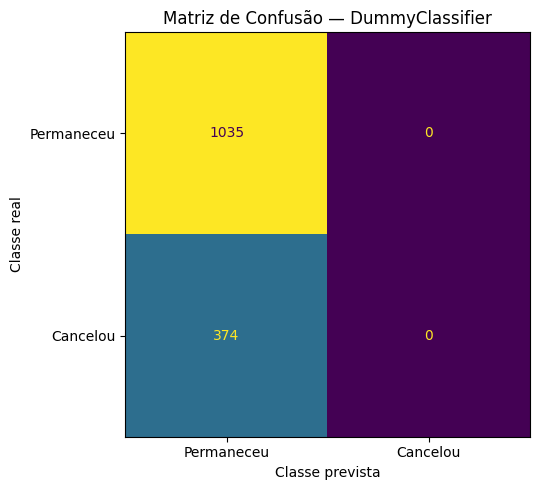

In [714]:
# ============================================================
# Matriz de confusão do DummyClassifier
# ============================================================

plot_confusion_matrix(
    y_true=y_test,
    y_pred=dummy_predictions,
    title="DummyClassifier"
)

### Principais observações

O **DummyClassifier** apresentou uma acurácia de **73,46%**, valor que corresponde aproximadamente à proporção da classe majoritária (**clientes que permaneceram**) observada durante a Análise Exploratória dos Dados.

A matriz de confusão confirma esse comportamento, mostrando que o modelo classificou **todos os 1.409 clientes do conjunto de teste como "Permaneceu"**. Dessa forma, foram corretamente classificados **1.035 clientes que permaneceram**, enquanto **374 clientes que efetivamente cancelaram** foram classificados incorretamente.

Como consequência, as métricas de **Precisão**, **Recall** e **F1-score** para a classe de cancelamento foram iguais a **0%**, evidenciando que o modelo não possui capacidade de identificar clientes com risco de churn.

Esse resultado demonstra, na prática, por que a **acurácia não deve ser utilizada isoladamente** em problemas de classificação com classes desbalanceadas. Embora o modelo apresente uma acurácia aparentemente elevada, ele falha completamente em seu principal objetivo: identificar clientes que cancelarão seus serviços.

Dessa forma, o DummyClassifier cumpre seu papel como **baseline**, estabelecendo uma referência mínima de desempenho que deverá ser superada pelos modelos candidatos nas próximas etapas.

## 8.4 Avaliação da Regressão Logística

Após a avaliação do modelo baseline, foi realizada a análise da **Regressão Logística**, primeiro modelo candidato treinado neste projeto.

Diferentemente do DummyClassifier, esse algoritmo utiliza as informações presentes nas variáveis para aprender padrões associados ao cancelamento dos clientes, permitindo realizar previsões com base nas características observadas durante o treinamento.

Inicialmente serão apresentadas as principais métricas de classificação obtidas no conjunto de teste. Em seguida, será analisada a matriz de confusão, permitindo comparar seu desempenho com o baseline e verificar sua capacidade de identificar clientes com risco de churn.

In [715]:
# ============================================================
# Avaliação da Regressão Logística
# ============================================================

logistic_results, logistic_predictions = evaluate_model(
    model=logistic_model,
    model_name="Regressão Logística",
    X_test=X_test,
    y_test=y_test
)

display(logistic_results)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,80.55,65.72,55.88,60.4


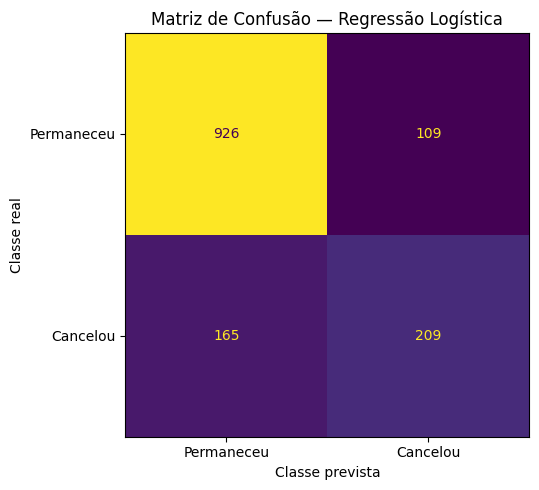

In [716]:
# ============================================================
# Matriz de confusão da Regressão Logística
# ============================================================

plot_confusion_matrix(
    y_true=y_test,
    y_pred=logistic_predictions,
    title="Regressão Logística"
)

### Principais observações

A **Regressão Logística** apresentou desempenho significativamente superior ao modelo baseline em todas as métricas avaliadas.

A acurácia aumentou de **73,46%** para **80,55%**, indicando uma melhora na capacidade geral de classificação. Entretanto, a principal evolução foi observada nas métricas relacionadas à identificação da classe de cancelamento.

Enquanto o DummyClassifier não foi capaz de identificar nenhum cliente que efetivamente cancelou seus serviços, a Regressão Logística obteve **Precisão de 65,72%**, **Recall de 55,88%** e **F1-score de 60,40%**, demonstrando que o modelo passou a aprender padrões presentes nos dados.

A matriz de confusão mostra que **209 dos 374 clientes que realmente cancelaram** foram corretamente identificados pelo modelo. Em contrapartida, **165 clientes que cancelaram** ainda foram classificados como permanência, enquanto **109 clientes que permaneceram** foram classificados incorretamente como cancelamento.

Esses resultados indicam que a Regressão Logística representa um avanço expressivo em relação ao baseline, estabelecendo uma nova referência de desempenho para comparação com os demais modelos candidatos.

## 8.5 Avaliação da Random Forest

Após a avaliação da Regressão Logística, foi realizada a análise da **Random Forest**, segundo modelo candidato treinado neste projeto.

Diferentemente da Regressão Logística, a Random Forest combina múltiplas árvores de decisão para identificar padrões mais complexos e relações não lineares entre as variáveis, o que pode resultar em maior capacidade de generalização para problemas de classificação.

Assim como nas avaliações anteriores, serão apresentadas inicialmente as principais métricas obtidas no conjunto de teste. Em seguida, será analisada a matriz de confusão, permitindo comparar o desempenho da Random Forest com os modelos avaliados anteriormente e verificar sua capacidade de identificar clientes com risco de churn.

In [717]:
# ============================================================
# Avaliação da Random Forest
# ============================================================

random_forest_results, random_forest_predictions = evaluate_model(
    model=random_forest_model,
    model_name="Random Forest",
    X_test=X_test,
    y_test=y_test
)

display(random_forest_results)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Random Forest,78.35,61.86,48.13,54.14


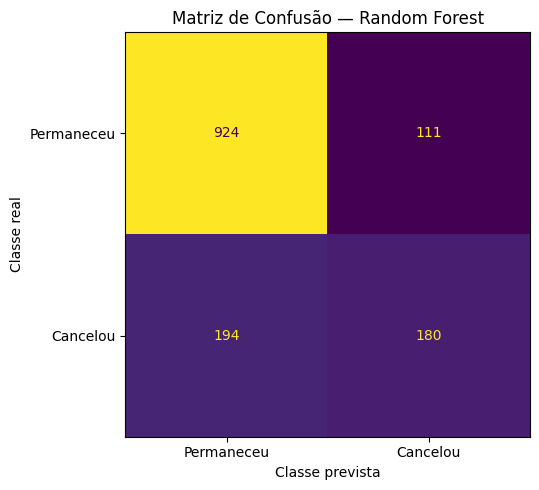

In [718]:
# ============================================================
# Matriz de confusão da Random Forest
# ============================================================

plot_confusion_matrix(
    y_true=y_test,
    y_pred=random_forest_predictions,
    title="Random Forest"
)

### Principais observações

A **Random Forest** apresentou desempenho superior ao modelo baseline, porém inferior ao obtido pela **Regressão Logística** em todas as métricas avaliadas.

O modelo alcançou **78,35% de acurácia**, **61,86% de Precisão**, **48,13% de Recall** e **54,14% de F1-score**, demonstrando capacidade de identificar clientes com risco de churn, embora com desempenho inferior ao primeiro modelo candidato.

A matriz de confusão mostra que **180 dos 374 clientes que realmente cancelaram** foram corretamente identificados, enquanto **194 clientes** foram classificados incorretamente como permanência. Além disso, **111 clientes que permaneceram** foram classificados de forma equivocada como cancelamento.

Embora a Random Forest seja um algoritmo capaz de modelar relações não lineares e mais complexas, neste conjunto de dados ela não superou a Regressão Logística. Esse resultado evidencia que modelos mais sofisticados não necessariamente apresentam melhor desempenho e reforça a importância de comparar diferentes abordagens utilizando as mesmas condições de treinamento e avaliação.

## 8.6 Comparação dos modelos

Após a avaliação individual de cada algoritmo, foi realizada uma comparação consolidada dos resultados obtidos.

Como todos os modelos foram treinados utilizando o mesmo conjunto de treinamento, o mesmo conjunto de teste e exatamente o mesmo pipeline de pré-processamento, as diferenças observadas nas métricas podem ser atribuídas principalmente às características de cada algoritmo de classificação.

A comparação a seguir reúne as principais métricas utilizadas neste projeto, permitindo identificar qual modelo apresentou o melhor desempenho na previsão de cancelamento de clientes.

In [719]:
# ============================================================
# Comparação dos modelos
# ============================================================

comparison = compare_models(
    dummy_results,
    logistic_results,
    random_forest_results
)

display(comparison)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,80.55,65.72,55.88,60.40
1,Random Forest,78.35,61.86,48.13,54.14
2,DummyClassifier,73.46,0.00,0.00,0.00


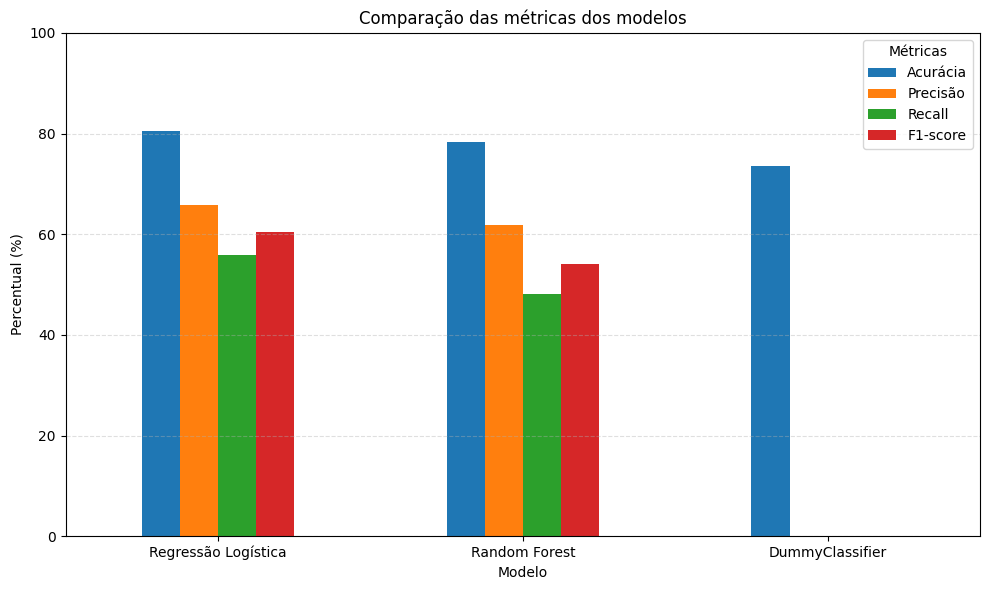

In [720]:
# ============================================================
# Comparação visual das métricas dos modelos
# ============================================================

comparison_plot = comparison.set_index("Modelo")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Comparação das métricas dos modelos")
ax.set_xlabel("Modelo")
ax.set_ylabel("Percentual (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Métricas")

plt.tight_layout()
plt.show()

### Principais observações

A tabela e o gráfico comparativo evidenciam que a **Regressão Logística** apresentou o melhor desempenho entre os modelos avaliados nesta etapa do projeto.

Embora o **DummyClassifier** tenha obtido uma acurácia relativamente elevada (**73,46%**), esse resultado decorre exclusivamente da predominância da classe majoritária no conjunto de dados. Como o modelo classificou todos os clientes como permanência, não foi capaz de identificar nenhum caso de cancelamento, resultando em valores nulos para **Precisão**, **Recall** e **F1-score**.

A **Random Forest** apresentou desempenho superior ao baseline, porém inferior ao da Regressão Logística em todas as métricas avaliadas. Na configuração utilizada neste projeto, o modelo identificou menos clientes com risco de churn e apresentou menor equilíbrio entre Precisão e Recall.

A comparação visual das métricas permite observar que a **Regressão Logística** alcançou os melhores resultados em **Acurácia (80,55%)**, **Precisão (65,72%)**, **Recall (55,88%)** e **F1-score (60,40%)**, demonstrando maior capacidade de identificar clientes com risco de cancelamento sem comprometer significativamente o desempenho geral do modelo.

Com base nos resultados obtidos nesta avaliação inicial, a **Regressão Logística** foi o modelo que apresentou o melhor equilíbrio entre as métricas analisadas, tornando-se o modelo de melhor desempenho entre os algoritmos avaliados nesta etapa do projeto.

## 8.7 Análise dos resultados iniciais

A avaliação realizada demonstrou que ambos os modelos candidatos superaram o **DummyClassifier**, confirmando que foram capazes de aprender padrões presentes nos dados e realizar previsões mais eficazes do que uma estratégia baseada apenas na classe majoritária.

Embora a **acurácia** tenha sido utilizada como uma das métricas de avaliação, ela não foi considerada suficiente para analisar o desempenho dos modelos isoladamente. Como identificado durante a Análise Exploratória dos Dados (EDA), o conjunto de dados apresenta predominância da classe de clientes que permaneceram na empresa. Esse comportamento ficou evidente no resultado do DummyClassifier, que alcançou uma acurácia de **73,46%**, mas não identificou corretamente nenhum cliente que efetivamente cancelou seus serviços. Por esse motivo, também foram analisadas as métricas de **Precisão**, **Recall** e **F1-score**, que forneceram uma visão mais completa da capacidade de identificação dos clientes com risco de churn.

Entre os modelos avaliados, a **Regressão Logística** apresentou o melhor desempenho em todas as métricas analisadas, demonstrando um bom equilíbrio entre a identificação dos clientes que cancelaram e a redução de classificações incorretas. A **Random Forest** também apresentou desempenho superior ao baseline, porém inferior ao da Regressão Logística na configuração utilizada neste projeto.

Nenhum dos modelos apresentou indícios claros de **underfitting**. Tanto a Regressão Logística quanto a Random Forest foram capazes de aprender padrões relevantes do conjunto de dados e superar significativamente o baseline. Entretanto, uma análise mais aprofundada da capacidade de generalização exigiria avaliações adicionais, como validação cruzada e ajuste de hiperparâmetros.

O tempo de treinamento dos modelos foi reduzido e plenamente adequado para o tamanho do conjunto de dados, permitindo a execução de todo o fluxo de treinamento e avaliação de forma eficiente.

De maneira geral, os resultados obtidos foram coerentes com as observações realizadas durante a EDA. As variáveis analisadas anteriormente demonstraram possuir relação com o cancelamento de clientes, e os modelos conseguiram explorar essas informações para produzir previsões significativamente superiores ao baseline. Nesta avaliação inicial, a **Regressão Logística** foi o modelo que apresentou o melhor desempenho entre os algoritmos testados.

# 9. Validação e otimização de hiperparâmetros

Após a avaliação inicial dos modelos candidatos, foi realizada uma etapa de validação e otimização de hiperparâmetros com o objetivo de verificar se seria possível melhorar o desempenho de um dos algoritmos avaliados.

Nesta etapa, será utilizada uma estratégia de busca controlada para identificar combinações de hiperparâmetros capazes de produzir melhores resultados, mantendo um equilíbrio entre desempenho e custo computacional.

Como este trabalho possui caráter introdutório e está estruturado como um **MVP (Minimum Viable Project)**, a busca será realizada sobre um conjunto reduzido de hiperparâmetros, priorizando a compreensão da metodologia empregada em vez da realização de uma otimização exaustiva.

Ao final desta etapa, o modelo otimizado será novamente avaliado utilizando o conjunto de teste, permitindo comparar seu desempenho com a configuração originalmente utilizada e verificar se a otimização produziu ganhos efetivos.

## 9.1 Estratégia de otimização

Na etapa anterior, os modelos candidatos foram avaliados utilizando suas configurações iniciais, permitindo identificar seu desempenho em condições equivalentes. Após essa comparação, optou-se por realizar uma etapa de otimização de hiperparâmetros para verificar se seria possível obter melhorias adicionais em um dos modelos avaliados.

O algoritmo escolhido para essa etapa foi a **Random Forest**. Embora tenha apresentado desempenho inferior ao da Regressão Logística, esse modelo possui diversos hiperparâmetros capazes de influenciar significativamente seu comportamento, tornando-o um bom candidato para otimização.

A busca pelos melhores hiperparâmetros será realizada utilizando o **GridSearchCV**, ferramenta do Scikit-learn que testa diferentes combinações de parâmetros de forma sistemática.

Para avaliar cada combinação de hiperparâmetros, será utilizada a técnica de **validação cruzada (Cross Validation)**. Nesse processo, o conjunto de treinamento é dividido em múltiplas partições (*folds*), permitindo que cada combinação seja treinada e validada diversas vezes. Ao final, o desempenho médio obtido durante essas validações é utilizado para selecionar a configuração mais promissora.

Essa estratégia reduz a dependência de uma única divisão entre treino e validação, produzindo uma estimativa mais estável do desempenho do modelo durante o processo de otimização.

Como este projeto possui caráter introdutório, será realizada uma busca reduzida de hiperparâmetros, suficiente para demonstrar a metodologia empregada sem aumentar excessivamente o custo computacional.

## 9.2 Definição da busca

Para realizar a otimização da **Random Forest**, foi definido um conjunto reduzido de hiperparâmetros considerados relevantes para o desempenho do algoritmo.

Como este projeto possui caráter introdutório, a busca foi planejada para equilibrar simplicidade, tempo de processamento e capacidade de demonstrar a metodologia de otimização.

Os hiperparâmetros selecionados foram:

- **n_estimators:** define a quantidade de árvores que compõem a floresta. Em geral, um número maior de árvores pode aumentar a estabilidade das previsões, porém também eleva o tempo de treinamento.

- **max_depth:** estabelece a profundidade máxima permitida para cada árvore. Limitar essa profundidade pode reduzir o risco de sobreajuste (*overfitting*), enquanto permitir profundidade ilimitada possibilita árvores mais complexas.

- **min_samples_split:** determina a quantidade mínima de amostras necessária para que um nó da árvore seja dividido. Valores maiores tendem a produzir árvores menos complexas e mais generalizáveis.

A combinação desses hiperparâmetros permite avaliar diferentes níveis de complexidade do modelo, mantendo uma quantidade reduzida de configurações compatível com o escopo deste MVP.

### Espaço de busca dos hiperparâmetros

O dicionário apresentado a seguir define o **espaço de busca** (*search space*) utilizado durante a otimização.

Cada chave representa um hiperparâmetro da Random Forest, enquanto cada lista contém os valores que poderão ser testados pelo **GridSearchCV**.

A partir dessas combinações, a ferramenta irá treinar e validar diferentes configurações do modelo, selecionando automaticamente aquela que apresentar o melhor desempenho médio durante a validação cruzada.

In [721]:
# ============================================================
# Espaço de busca dos hiperparâmetros
# ============================================================

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

param_grid

{'classifier__n_estimators': [100, 200],
 'classifier__max_depth': [None, 10, 20],
 'classifier__min_samples_split': [2, 5]}

In [722]:
# ============================================================
# Quantidade de combinações avaliadas
# ============================================================

print(f"Total de combinações: {len(ParameterGrid(param_grid))}")

Total de combinações: 12


### Principais observações

Foi definido um espaço de busca contendo combinações de três hiperparâmetros da Random Forest: número de árvores (`n_estimators`), profundidade máxima das árvores (`max_depth`) e quantidade mínima de amostras para divisão dos nós (`min_samples_split`).

Ao todo, serão avaliadas **12 combinações** de hiperparâmetros. Esse conjunto foi escolhido por representar diferentes níveis de complexidade do modelo, mantendo um custo computacional compatível com o objetivo deste MVP.

Na próxima etapa, essas combinações serão avaliadas por meio do **GridSearchCV** utilizando validação cruzada, permitindo identificar automaticamente a configuração que apresentar o melhor desempenho médio durante o treinamento.

## 9.3 Execução da busca

Após a definição do espaço de busca, será configurado o processo de otimização utilizando o **GridSearchCV**, ferramenta do Scikit-learn responsável por testar sistematicamente todas as combinações de hiperparâmetros especificadas.

Antes da execução da busca, será apresentado um resumo da estratégia de otimização, incluindo a quantidade de combinações que serão avaliadas, o número de *folds* utilizados na validação cruzada e o total de treinamentos que serão realizados.

Durante a execução, cada combinação de hiperparâmetros será treinada e validada utilizando **validação cruzada com 5 folds**. Ao final desse processo, será calculado o desempenho médio de cada configuração, permitindo selecionar automaticamente aquela que apresentar os melhores resultados.

Como critério de avaliação durante a busca, será utilizada a métrica **F1-score**, por representar um equilíbrio entre Precisão e Recall. Essa escolha é particularmente adequada para este problema, no qual o objetivo é identificar clientes com risco de churn sem priorizar excessivamente apenas uma dessas métricas.

Como a variável-alvo é representada pelas categorias "Yes" e "No", foi utilizado um scorer personalizado para definir explicitamente "Yes" como classe positiva durante o processo de otimização.

In [723]:
# ============================================================
# Métrica utilizada na otimização
# ============================================================

f1_scorer = make_scorer(
    f1_score,
    pos_label="Yes"
)

In [724]:
# ============================================================
# Configuração do GridSearchCV
# ============================================================

grid_search = GridSearchCV(
    estimator=create_pipeline(
        RandomForestClassifier(
            random_state=RANDOM_STATE
        )
    ),
    param_grid=param_grid,
    scoring=f1_scorer,
    cv=5,
    n_jobs=-1
)

In [725]:
# ============================================================
# Resumo da estratégia de otimização
# ============================================================

total_combinations = len(ParameterGrid(param_grid))
total_trainings = total_combinations * 5

print(f"Espaço de busca: {total_combinations} combinações")
print("Validação cruzada: 5 folds")
print(f"Total de treinamentos: {total_trainings}")

Espaço de busca: 12 combinações
Validação cruzada: 5 folds
Total de treinamentos: 60


In [726]:
# ============================================================
# Execução da busca pelos melhores hiperparâmetros
# ============================================================

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneHotEncoder(ha...
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring=make_scorer(f1_score, response_method='predict', pos_label=Yes))

### Principais observações

Foi configurada uma busca utilizando o **GridSearchCV**, considerando um espaço de busca composto por **12 combinações** de hiperparâmetros para a Random Forest.

Com a utilização de **validação cruzada com 5 folds**, foram realizados **60 treinamentos** durante o processo de otimização, permitindo avaliar cada combinação de forma consistente antes da seleção da melhor configuração.

Como critério de otimização, foi utilizado o **F1-score**, por representar um equilíbrio entre Precisão e Recall. Como a variável-alvo é composta pelas categorias **"Yes"** e **"No"**, foi definido um *scorer* personalizado para considerar explicitamente **"Yes"** como a classe positiva durante o processo de validação cruzada.

Na próxima etapa, será apresentada a configuração selecionada pelo processo de otimização, bem como seu desempenho médio durante a validação cruzada.

## 9.4 Melhor configuração encontrada

Após a conclusão da busca, o **GridSearchCV** selecionou automaticamente a combinação de hiperparâmetros que apresentou o melhor desempenho médio durante a validação cruzada.

Além da configuração escolhida, será apresentada a pontuação média obtida durante o processo de otimização, permitindo compreender o desempenho estimado do modelo antes de sua avaliação no conjunto de teste.

Esses resultados servirão como base para a construção do modelo otimizado, que será comparado posteriormente com a configuração original da Random Forest.

In [727]:
# ============================================================
# Melhor configuração encontrada
# ============================================================

best_params = (
    pd.DataFrame(
        grid_search.best_params_.items(),
        columns=["Hiperparâmetro", "Valor"]
    )
)

display(best_params)

,Hiperparâmetro,Valor
0,classifier__max_depth,10
1,classifier__min_samples_split,2
2,classifier__n_estimators,100


In [728]:
# ============================================================
# Melhor desempenho na validação cruzada
# ============================================================

print(
    f"Melhor F1-score médio (validação cruzada): "
    f"{grid_search.best_score_:.4f}"
)

Melhor F1-score médio (validação cruzada): 0.5769


In [729]:
# ============================================================
# Melhor modelo encontrado
# ============================================================

grid_search.best_estimator_

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['SeniorCitizen', 'gender',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=10, random_state=42))])

### Principais observações

O **GridSearchCV** identificou como melhor configuração uma Random Forest com **100 árvores**, profundidade máxima de **10 níveis** e **2 amostras mínimas** para divisão dos nós.

Entre os hiperparâmetros avaliados, apenas **max_depth** foi alterado em relação à configuração originalmente utilizada. Esse resultado indica que limitar a profundidade das árvores contribuiu para um melhor desempenho médio durante a validação cruzada, reduzindo a complexidade do modelo sem comprometer sua capacidade de aprendizagem.

A melhor configuração obteve um **F1-score médio de 0,5769** durante a validação cruzada, representando o desempenho estimado do modelo ao longo do processo de otimização.

Na próxima etapa, essa configuração será avaliada utilizando o mesmo conjunto de teste empregado nas avaliações anteriores, permitindo verificar se a otimização produziu ganhos efetivos em relação à Random Forest original.

## 9.5 Avaliação do modelo otimizado

Após a identificação da melhor combinação de hiperparâmetros, o modelo otimizado será avaliado utilizando o mesmo conjunto de teste empregado nas etapas anteriores.

Essa avaliação permitirá verificar se as melhorias observadas durante a validação cruzada também são refletidas em dados não utilizados durante o treinamento e a otimização.

Para garantir uma comparação justa entre os modelos, serão utilizadas as mesmas métricas de classificação empregadas anteriormente: **Acurácia**, **Precisão**, **Recall** e **F1-score**. Em seguida, será analisada a matriz de confusão, permitindo comparar o comportamento da Random Forest otimizada com sua configuração original.

In [730]:
# ============================================================
# Avaliação da Random Forest otimizada
# ============================================================

optimized_results, optimized_predictions = evaluate_model(
    model=grid_search.best_estimator_,
    model_name="Random Forest Otimizada",
    X_test=X_test,
    y_test=y_test
)

display(optimized_results)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Random Forest Otimizada,80.55,66.56,53.74,59.47


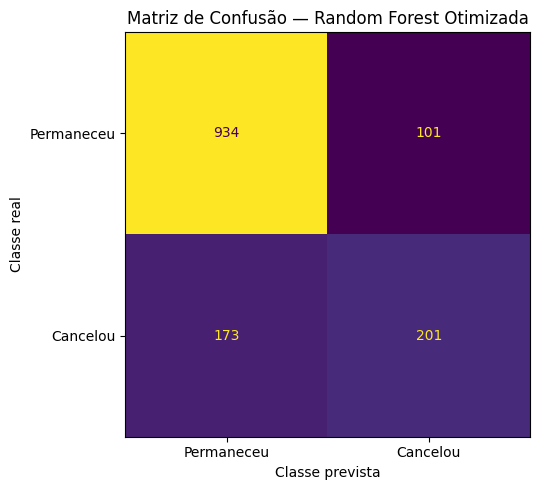

In [731]:
# ============================================================
# Matriz de confusão da Random Forest otimizada
# ============================================================

plot_confusion_matrix(
    y_true=y_test,
    y_pred=optimized_predictions,
    title="Random Forest Otimizada"
)

### Principais observações

A otimização dos hiperparâmetros resultou em melhorias consistentes no desempenho da **Random Forest** em relação à sua configuração original.

Após o ajuste dos hiperparâmetros, o modelo passou a apresentar **80,55% de acurácia**, **66,56% de Precisão**, **53,74% de Recall** e **59,47% de F1-score**, superando os resultados obtidos anteriormente em todas as métricas avaliadas.

A matriz de confusão confirma essa evolução, mostrando aumento na quantidade de clientes corretamente classificados tanto na classe **"Permaneceu"** quanto na classe **"Cancelou"**, além da redução dos erros de classificação.

Embora a **Regressão Logística** ainda apresente um desempenho ligeiramente superior em **Recall** e **F1-score**, a diferença entre os modelos tornou-se bastante pequena após a otimização da Random Forest.

Esses resultados demonstram que o ajuste de hiperparâmetros pode produzir ganhos relevantes de desempenho, mesmo quando realizado sobre um espaço de busca reduzido e compatível com o escopo de um MVP.

## 9.6 Comparação dos modelos após a otimização

Após a avaliação da Random Forest otimizada, foi realizada uma nova comparação entre todos os modelos analisados ao longo deste projeto.

Essa comparação permite verificar o impacto da otimização de hiperparâmetros sobre o desempenho da Random Forest e posicionar sua versão otimizada em relação aos demais modelos avaliados.

Assim como nas etapas anteriores, serão consideradas as métricas de **Acurácia**, **Precisão**, **Recall** e **F1-score**, permitindo uma análise consolidada dos resultados obtidos.

In [732]:
# ============================================================
# Comparação final dos modelos
# ============================================================

comparison_final = compare_models(
    dummy_results,
    logistic_results,
    random_forest_results,
    optimized_results
)

display(comparison_final)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,80.55,65.72,55.88,60.40
1,Random Forest Otimizada,80.55,66.56,53.74,59.47
2,Random Forest,78.35,61.86,48.13,54.14
3,DummyClassifier,73.46,0.00,0.00,0.00


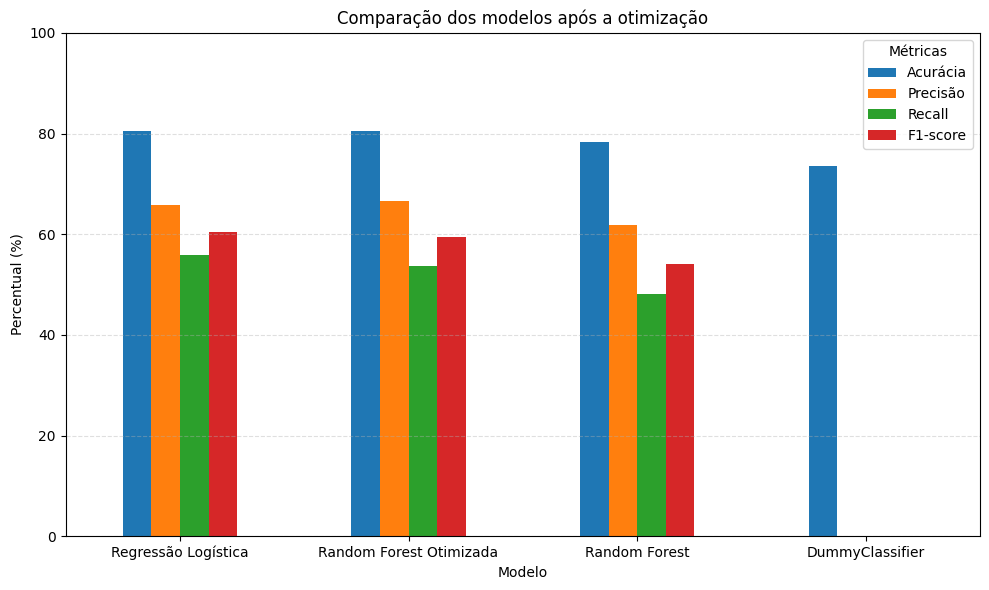

In [733]:
comparison_plot = comparison_final.set_index("Modelo")

ax = comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Comparação dos modelos após a otimização")
ax.set_xlabel("Modelo")
ax.set_ylabel("Percentual (%)")
ax.set_ylim(0, 100)

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.legend(title="Métricas")

plt.tight_layout()
plt.show()

### Principais observações

A comparação consolidada mostra que a otimização dos hiperparâmetros aproximou significativamente o desempenho da **Random Forest** ao da **Regressão Logística**, reduzindo a diferença observada na avaliação inicial dos modelos.

A **Regressão Logística** permaneceu como o modelo de melhor desempenho geral, apresentando o maior **F1-score (60,40%)** e o maior **Recall (55,88%)**, métricas consideradas especialmente relevantes para o problema de previsão de churn.

Por sua vez, a **Random Forest Otimizada** apresentou melhorias em relação à sua configuração original em todas as métricas avaliadas, alcançando **80,55% de Acurácia**, **66,56% de Precisão**, **53,74% de Recall** e **59,47% de F1-score**. Além disso, tornou-se o modelo com a maior **Precisão** entre os algoritmos avaliados.

Os resultados demonstram que a otimização de hiperparâmetros foi capaz de produzir ganhos relevantes de desempenho utilizando um espaço de busca reduzido, tornando a Random Forest otimizada uma alternativa competitiva à Regressão Logística para este conjunto de dados.

## 9.7 Discussão da otimização

- ### A otimização melhorou o resultado em relação ao modelo inicial?

Sim. A otimização dos hiperparâmetros resultou em melhorias consistentes na Random Forest, aumentando todas as métricas avaliadas em relação à configuração original. O modelo passou a apresentar maior Acurácia, Precisão, Recall e F1-score, além de reduzir os erros observados na matriz de confusão.

- ### A busca foi limitada por tempo, custo ou tamanho da base?

Sim. Como este projeto possui caráter de MVP, foi definido um espaço de busca reduzido, composto por apenas três hiperparâmetros e doze combinações possíveis. Essa decisão permitiu demonstrar a aplicação do GridSearchCV e da validação cruzada sem aumentar significativamente o custo computacional.

- ### Os hiperparâmetros escolhidos fazem sentido?

Sim. O GridSearchCV manteve os valores padrão para `n_estimators` e `min_samples_split`, indicando que essas configurações já eram adequadas para este conjunto de dados. Em contrapartida, limitou a profundidade máxima das árvores (`max_depth = 10`), sugerindo que árvores menos profundas apresentaram melhor capacidade de generalização durante a validação cruzada.

- ### Você testaria outras combinações se tivesse mais tempo?

Sim. Em um trabalho futuro, poderiam ser avaliados outros hiperparâmetros, como `max_features`, `min_samples_leaf` e diferentes quantidades de árvores, além da utilização de estratégias como `RandomizedSearchCV` ou espaços de busca mais amplos. Também seria possível comparar outros algoritmos baseados em árvores, como Gradient Boosting, XGBoost ou LightGBM.

--

De forma geral, a otimização demonstrou que pequenos ajustes nos hiperparâmetros foram suficientes para melhorar significativamente o desempenho da Random Forest. Apesar desses ganhos, a **Regressão Logística** permaneceu como o modelo de melhor desempenho geral neste projeto, apresentando o maior equilíbrio entre Precisão, Recall e F1-score.

# 10. Avaliação final no conjunto de teste

Após a comparação entre os modelos candidatos e a etapa de otimização de hiperparâmetros, foi selecionado o modelo que apresentou o melhor desempenho geral para o problema de previsão de churn.

Nesta seção, será realizada a avaliação final desse modelo utilizando o conjunto de teste, que permaneceu separado durante todas as etapas de treinamento, seleção de modelos e otimização de hiperparâmetros.

Essa abordagem garante uma estimativa mais confiável da capacidade de generalização do modelo, uma vez que os dados utilizados nesta avaliação não participaram do processo de aprendizado nem influenciaram a escolha da configuração final.

Além da apresentação das métricas de desempenho, serão discutidos os principais erros de classificação, possíveis sinais de sobreajuste (*overfitting*) ou subajuste (*underfitting*), bem como as limitações da solução proposta.

## 10.1 Escolha do modelo final

Após a avaliação dos modelos candidatos e da Random Forest otimizada, foi necessário selecionar um único modelo para representar a solução final deste projeto.

Essa decisão foi baseada principalmente no **F1-score**, métrica escolhida para este problema por equilibrar **Precisão** e **Recall**, além da análise conjunta das demais métricas e da capacidade de generalização apresentada pelos modelos.

Na sequência, será apresentado o modelo selecionado para a avaliação final no conjunto de teste.

In [734]:
# ============================================================
# Escolha do modelo final
# ============================================================

final_model = logistic_model
final_model_name = "Regressão Logística"

print(f"Modelo selecionado: {final_model_name}")

Modelo selecionado: Regressão Logística


## 10.2 Avaliação final

Após a seleção da **Regressão Logística** como modelo final deste projeto, foi realizada sua avaliação utilizando o conjunto de teste, que permaneceu separado durante todas as etapas de treinamento, seleção de modelos e otimização de hiperparâmetros.

Como esse conjunto de dados não participou do processo de aprendizado, os resultados apresentados nesta etapa representam uma estimativa mais realista da capacidade de generalização do modelo para novos clientes.

Serão apresentadas as principais métricas de classificação (**Acurácia**, **Precisão**, **Recall** e **F1-score**), seguidas da matriz de confusão, permitindo analisar o desempenho do modelo e os tipos de erros mais frequentes.

In [735]:
# ============================================================
# Avaliação final do modelo
# ============================================================

display(logistic_results)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,80.55,65.72,55.88,60.4


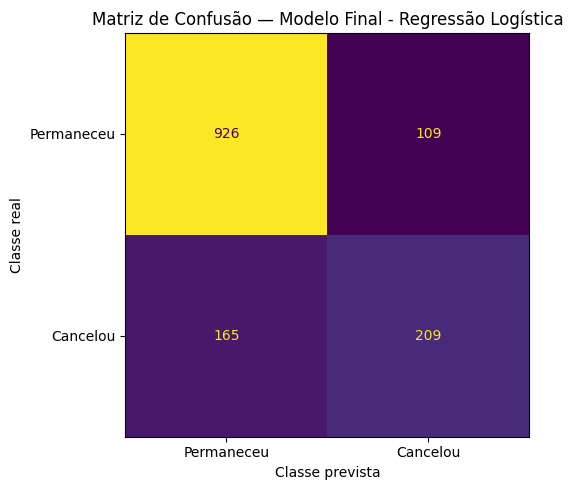

In [736]:
# ============================================================
# Matriz de confusão do modelo final
# ============================================================

plot_confusion_matrix(
    y_true=y_test,
    y_pred=logistic_predictions,
    title="Modelo Final - Regressão Logística"
)

In [737]:
# ============================================================
# Comparação com o baseline
# ============================================================

baseline_comparison = compare_models(
    dummy_results,
    logistic_results
)

display(baseline_comparison)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,80.55,65.72,55.88,60.4
1,DummyClassifier,73.46,0.00,0.00,0.0


In [738]:
# ============================================================
# Ganho em relação ao baseline
# ============================================================

metric_columns = [
    "Acurácia",
    "Precisão",
    "Recall",
    "F1-score"
]

improvement = (
    logistic_results[metric_columns].iloc[0]
    - dummy_results[metric_columns].iloc[0]
).to_frame(name="Ganho (%)")

display(improvement)

,Ganho (%)
Acurácia,7.09
Precisão,65.72
Recall,55.88
F1-score,60.40


### Principais observações

A avaliação final confirma que a **Regressão Logística** apresentou o melhor desempenho geral entre os modelos analisados neste projeto.

Em comparação com o **DummyClassifier**, utilizado como baseline, o modelo apresentou melhorias expressivas em todas as métricas de classificação. Enquanto o baseline apenas reproduz a classe majoritária e não consegue identificar clientes com risco de cancelamento, a Regressão Logística foi capaz de distinguir ambas as classes, alcançando **80,55% de Acurácia**, **65,72% de Precisão**, **55,88% de Recall** e **60,40% de F1-score**.

A matriz de confusão demonstra que o modelo identifica corretamente a maior parte dos clientes que permaneceram na empresa e também consegue detectar uma parcela significativa dos clientes que cancelaram o serviço, apresentando um equilíbrio adequado entre acertos e erros de classificação.

Na próxima etapa, será realizada uma análise mais detalhada dos erros cometidos pelo modelo, bem como uma discussão sobre possíveis limitações e oportunidades de melhoria da solução proposta.

## 10.3 Análise de erros e limitações

Embora a Regressão Logística tenha apresentado o melhor desempenho entre os modelos avaliados, nenhuma solução de Machine Learning é capaz de realizar previsões perfeitas.

Nesta etapa, será realizada uma análise crítica dos resultados obtidos, buscando compreender os principais tipos de erro cometidos pelo modelo, discutir possíveis sinais de sobreajuste (*overfitting*) ou subajuste (*underfitting*) e avaliar as limitações da solução proposta.

Também serão consideradas as características do conjunto de dados e as restrições metodológicas do projeto, permitindo contextualizar os resultados e identificar oportunidades para trabalhos futuros.

- ### Quais tipos de erro o modelo comete mais?

A matriz de confusão mostra que o modelo ainda apresenta uma quantidade considerável de **falsos negativos**, ou seja, clientes que realmente cancelaram o serviço, mas foram classificados como clientes que permaneceriam na empresa. Esse tipo de erro é especialmente relevante em problemas de previsão de churn, pois representa oportunidades perdidas de retenção de clientes.

Também são observados **falsos positivos**, embora em menor quantidade. Nesses casos, clientes que permaneceriam na empresa são classificados como potenciais cancelamentos, podendo levar à realização de ações de retenção desnecessárias.

- ### Há sinais de overfitting ou underfitting?

Com base nos resultados obtidos, não foram observados indícios claros de **underfitting**, uma vez que o modelo apresentou desempenho significativamente superior ao baseline e conseguiu identificar padrões relevantes presentes nos dados.

Também não há evidências suficientes para afirmar a existência de **overfitting**, pois a avaliação final foi realizada em um conjunto de teste separado, que não participou das etapas de treinamento nem da otimização dos hiperparâmetros. Entretanto, uma análise mais conclusiva exigiria técnicas adicionais, como validação cruzada mais abrangente, curvas de aprendizado ou comparação explícita entre desempenho em treino e teste.

- ### A métrica escolhida captura bem o objetivo do problema?

Sim. O **F1-score** mostrou-se adequado para este problema por equilibrar **Precisão** e **Recall**, reduzindo a influência do desbalanceamento entre as classes observado durante a análise exploratória dos dados. A utilização dessa métrica permitiu avaliar de forma mais representativa a capacidade do modelo em identificar clientes com risco de churn.

- ### Há viés, limitação de dados ou risco de generalização?

Sim. O modelo foi desenvolvido utilizando um único conjunto de dados, contendo informações de clientes de uma empresa específica de telecomunicações. Dessa forma, seu desempenho pode não ser diretamente generalizável para empresas de outros setores ou para bases de dados com características diferentes.

Além disso, a qualidade das previsões depende diretamente das variáveis disponíveis no conjunto de dados. Informações adicionais sobre comportamento dos clientes, histórico de atendimento ou perfil de consumo poderiam contribuir para melhorar o desempenho do modelo.

- ### Em quais cenários o modelo não deveria ser usado?

Este modelo não deve ser utilizado como único critério para decisões estratégicas relacionadas à retenção de clientes. Suas previsões devem ser interpretadas como um mecanismo de apoio à decisão, complementando análises realizadas por especialistas de negócio e outras fontes de informação.

Também não é recomendada sua utilização em contextos diferentes daqueles representados pelo conjunto de dados utilizado neste projeto sem que sejam realizadas novas etapas de treinamento, validação e avaliação.

# 11. Comparação final dos modelos

Ao longo deste projeto foram avaliados diferentes modelos de classificação para o problema de previsão de churn, incluindo um modelo de referência (*baseline*), dois modelos candidatos e uma versão otimizada da Random Forest.

Nesta seção, é apresentada uma síntese comparativa dos resultados obtidos, reunindo as principais métricas de desempenho e observações relevantes para cada modelo.

Essa comparação permite justificar de forma objetiva a escolha da **Regressão Logística** como modelo final do projeto.

In [739]:
# ============================================================
# Comparação final dos modelos
# ============================================================

display(comparison_final)

,Modelo,Acurácia,Precisão,Recall,F1-score
0,Regressão Logística,80.55,65.72,55.88,60.40
1,Random Forest Otimizada,80.55,66.56,53.74,59.47
2,Random Forest,78.35,61.86,48.13,54.14
3,DummyClassifier,73.46,0.00,0.00,0.00


In [740]:
# ============================================================
# Síntese comparativa dos modelos
# ============================================================

summary = pd.DataFrame({
    "Modelo": [
        "DummyClassifier",
        "Regressão Logística",
        "Random Forest",
        "Random Forest Otimizada"
    ],
    "Métrica principal": [
        "F1-score = 0,00%",
        "F1-score = 60,40%",
        "F1-score = 54,14%",
        "F1-score = 59,47%"
    ],
    "Outras métricas": [
        "Acurácia = 73,46%",
        "Acurácia = 80,55%",
        "Acurácia = 78,35%",
        "Acurácia = 80,55%"
    ],
    "Tempo de treinamento": [
        "Muito baixo",
        "Baixo",
        "Baixo",
        "Moderado"
    ],
    "Observações": [
        "Baseline (classe majoritária)",
        "Melhor equilíbrio entre Precisão, Recall e F1-score",
        "Desempenho inferior ao modelo final",
        "Melhorou após a otimização e apresentou a maior Precisão"
    ],
    "Modelo final": [
        "Não",
        "Sim",
        "Não",
        "Não"
    ]
})

display(summary)

,Modelo,Métrica principal,Outras métricas,Tempo de treinamento,Observações,Modelo final
0,DummyClassifier,"F1-score = 0,00%","Acurácia = 73,46%",Muito baixo,Baseline (classe majoritária),Não
1,Regressão Logística,"F1-score = 60,40%","Acurácia = 80,55%",Baixo,"Melhor equilíbrio entre Precisão, Recall e F1-...",Sim
2,Random Forest,"F1-score = 54,14%","Acurácia = 78,35%",Baixo,Desempenho inferior ao modelo final,Não
3,Random Forest Otimizada,"F1-score = 59,47%","Acurácia = 80,55%",Moderado,Melhorou após a otimização e apresentou a maio...,Não


### Principais observações

A comparação final confirma que todos os modelos candidatos superaram o **DummyClassifier**, demonstrando capacidade de aprender padrões relevantes do conjunto de dados.

A **Regressão Logística** apresentou o melhor desempenho geral, obtendo o maior **F1-score**, além de manter um bom equilíbrio entre Precisão, Recall e Acurácia. Por esse motivo, foi escolhida como modelo final deste projeto.

A **Random Forest** apresentou melhorias significativas após a etapa de otimização de hiperparâmetros, reduzindo a diferença em relação à Regressão Logística e tornando-se uma alternativa competitiva. Apesar disso, seu desempenho permaneceu ligeiramente inferior na métrica principal adotada neste estudo.

De forma geral, os resultados demonstram a importância da comparação entre diferentes algoritmos e da otimização de hiperparâmetros como etapas fundamentais no desenvolvimento de modelos de Machine Learning.

# 12. Boas práticas e rastreabilidade

Ao longo deste projeto foram adotadas diversas práticas com o objetivo de garantir a reprodutibilidade dos experimentos, a organização do código e a rastreabilidade das decisões metodológicas.

Nesta seção são registradas as principais escolhas realizadas durante o desenvolvimento do modelo, bem como suas respectivas justificativas e impactos esperados sobre os resultados obtidos.

Esse registro facilita a compreensão do fluxo de trabalho, além de permitir que o experimento seja reproduzido ou expandido em trabalhos futuros.

## 12.1 Configuração do experimento

A tabela a seguir resume as principais configurações utilizadas durante o desenvolvimento deste projeto.

In [741]:
# ============================================================
# Configuração do experimento
# ============================================================

experiment_config = pd.DataFrame({
    "Item": [
        "Seed aleatória",
        "Estratégia de divisão",
        "Proporção treino/teste",
        "Validação cruzada",
        "Métrica principal",
        "Pipeline",
        "Pré-processamento",
        "Otimização"
    ],
    "Configuração": [
        RANDOM_STATE,
        "Holdout estratificado",
        "80% / 20%",
        "5 folds",
        "F1-score",
        "Scikit-learn Pipeline",
        "ColumnTransformer",
        "GridSearchCV"
    ]
})

display(experiment_config)

,Item,Configuração
0,Seed aleatória,42
1,Estratégia de divisão,Holdout estratificado
2,Proporção treino/teste,80% / 20%
3,Validação cruzada,5 folds
4,Métrica principal,F1-score
5,Pipeline,Scikit-learn Pipeline
6,Pré-processamento,ColumnTransformer
7,Otimização,GridSearchCV


## 12.2 Registro das decisões

Durante o desenvolvimento do projeto, diversas decisões metodológicas foram tomadas com o objetivo de construir um fluxo consistente de preparação dos dados, treinamento e avaliação dos modelos.

A tabela a seguir resume as principais decisões adotadas, suas justificativas e o impacto esperado sobre o desempenho do modelo.

In [742]:
# ============================================================
# Registro das principais decisões do projeto
# ============================================================

decision_log = pd.DataFrame({
    "Decisão": [
        "Utilizar Holdout estratificado",
        "Converter TotalCharges para numérico",
        "Imputar valores ausentes pela mediana",
        "Aplicar StandardScaler nas variáveis numéricas",
        "Codificar variáveis categóricas com OneHotEncoder",
        "Utilizar Pipeline",
        "Adotar F1-score como métrica principal",
        "Comparar diferentes modelos",
        "Otimizar a Random Forest com GridSearchCV"
    ],
    "Justificativa": [
        "Preservar a proporção entre as classes.",
        "Permitir o uso da variável pelos modelos.",
        "Robustez à assimetria da distribuição.",
        "Padronizar as escalas das variáveis.",
        "Transformar categorias em atributos numéricos.",
        "Evitar vazamento de dados.",
        "Equilibrar Precisão e Recall.",
        "Selecionar o melhor modelo.",
        "Buscar melhor desempenho."
    ],
    "Impacto esperado": [
        "Avaliação mais representativa.",
        "Maior qualidade dos dados.",
        "Menor influência de valores extremos.",
        "Melhor desempenho dos modelos lineares.",
        "Compatibilidade com os modelos.",
        "Maior confiabilidade da avaliação.",
        "Melhor avaliação da classe minoritária.",
        "Escolha baseada em evidências.",
        "Melhor capacidade de generalização."
    ]
})

display(
    decision_log.style
    .set_properties(
        subset=["Justificativa", "Impacto esperado"],
        **{
            "white-space": "normal",
            "text-align": "right"
        }
    )
)

,Decisão,Justificativa,Impacto esperado
0,Utilizar Holdout estratificado,Preservar a proporção entre as classes.,Avaliação mais representativa.
1,Converter TotalCharges para numérico,Permitir o uso da variável pelos modelos.,Maior qualidade dos dados.
2,Imputar valores ausentes pela mediana,Robustez à assimetria da distribuição.,Menor influência de valores extremos.
3,Aplicar StandardScaler nas variáveis numéricas,Padronizar as escalas das variáveis.,Melhor desempenho dos modelos lineares.
4,Codificar variáveis categóricas com OneHotEncoder,Transformar categorias em atributos numéricos.,Compatibilidade com os modelos.
5,Utilizar Pipeline,Evitar vazamento de dados.,Maior confiabilidade da avaliação.
6,Adotar F1-score como métrica principal,Equilibrar Precisão e Recall.,Melhor avaliação da classe minoritária.
7,Comparar diferentes modelos,Selecionar o melhor modelo.,Escolha baseada em evidências.
8,Otimizar a Random Forest com GridSearchCV,Buscar melhor desempenho.,Melhor capacidade de generalização.


## 12.3 Limitações conhecidas

Embora o modelo tenha apresentado resultados satisfatórios para o conjunto de dados utilizado, algumas limitações devem ser consideradas durante a interpretação dos resultados.

Essas limitações não invalidam o estudo, mas indicam oportunidades de aprimoramento para trabalhos futuros.

In [743]:
# ============================================================
# Limitações do projeto
# ============================================================

limitations = pd.DataFrame({
    "Limitação": [
        "Conjunto de dados de uma única empresa",
        "Espaço de busca reduzido no GridSearchCV",
        "Número limitado de algoritmos avaliados",
        "Ausência de validação externa",
        "Não utilização de técnicas de balanceamento"
    ],
    "Possível impacto": [
        "Menor capacidade de generalização.",
        "Possibilidade de configurações melhores.",
        "Outros algoritmos podem apresentar melhor desempenho.",
        "Resultados dependem deste conjunto de dados.",
        "Possível melhoria na identificação da classe minoritária."
    ]
})

display(
    limitations.style
    .set_properties(
        subset=["Possível impacto"],
        **{
            "white-space": "normal",
            "text-align": "right"
        }
    )
)

,Limitação,Possível impacto
0,Conjunto de dados de uma única empresa,Menor capacidade de generalização.
1,Espaço de busca reduzido no GridSearchCV,Possibilidade de configurações melhores.
2,Número limitado de algoritmos avaliados,Outros algoritmos podem apresentar melhor desempenho.
3,Ausência de validação externa,Resultados dependem deste conjunto de dados.
4,Não utilização de técnicas de balanceamento,Possível melhoria na identificação da classe minoritária.


# 13. Conclusão

O objetivo deste projeto foi desenvolver um modelo de **Machine Learning** capaz de prever o cancelamento de clientes (*Churn*) a partir de informações cadastrais e do histórico de contratação de serviços de uma empresa de telecomunicações.

Para isso, foi desenvolvido um fluxo completo de Ciência de Dados, contemplando as etapas de preparação dos dados, análise exploratória, pré-processamento, treinamento, avaliação e otimização de modelos de classificação, seguindo boas práticas para evitar vazamento de dados e garantir a reprodutibilidade dos experimentos.

Entre os modelos avaliados, a **Regressão Logística** apresentou o melhor desempenho geral, alcançando **80,55% de Acurácia**, **65,72% de Precisão**, **55,88% de Recall** e **60,40% de F1-score**, sendo escolhida como modelo final deste projeto. Embora a **Random Forest** tenha apresentado melhorias após a otimização de hiperparâmetros, seu desempenho permaneceu ligeiramente inferior na métrica principal adotada neste estudo.

A comparação com o **DummyClassifier**, utilizado como baseline, demonstrou que todos os modelos candidatos foram capazes de aprender padrões relevantes presentes nos dados, confirmando que a utilização de algoritmos de Machine Learning trouxe ganhos significativos em relação a uma abordagem baseada apenas na classe majoritária.

Além dos resultados obtidos, este projeto permitiu consolidar conhecimentos relacionados à construção de pipelines de pré-processamento, tratamento de valores ausentes, codificação de variáveis categóricas, validação cruzada, otimização de hiperparâmetros e avaliação de modelos utilizando diferentes métricas de classificação.

Como trabalhos futuros, podem ser exploradas estratégias adicionais, como técnicas de balanceamento das classes, ampliação do espaço de busca de hiperparâmetros, avaliação de algoritmos mais avançados e validação utilizando novos conjuntos de dados, permitindo investigar possíveis ganhos adicionais de desempenho e capacidade de generalização.

De forma geral, os resultados obtidos demonstram que a metodologia adotada foi adequada para o problema proposto e evidenciam a importância de uma abordagem estruturada na construção e avaliação de modelos de Machine Learning.


# 14. Salvamento de artefatos

Embora este projeto tenha sido desenvolvido com fins educacionais, é uma boa prática preservar os principais artefatos produzidos durante o treinamento dos modelos.

O salvamento desses objetos permite reutilizar o modelo treinado sem necessidade de repetir todo o processo de treinamento e pré-processamento, além de facilitar futuras etapas de implantação (*deployment*) ou integração com outras aplicações.

Nesta seção serão salvos o modelo final e algumas tabelas produzidas durante a avaliação dos modelos.

In [744]:
# ============================================================
# Salvamento do modelo final
# ============================================================

if final_model is not None:
    joblib.dump(final_model, "modelo_final.pkl")
    print(f"{final_model_name} salvo como 'modelo_final.pkl'.")

Regressão Logística salvo como 'modelo_final.pkl'.


In [745]:
# ============================================================
# Salvamento das tabelas produzidas
# ============================================================

comparison_final.to_csv(
    "comparacao_modelos.csv",
    index=False
)

summary.to_csv(
    "resumo_modelos.csv",
    index=False
)

print("Tabelas salvas com sucesso.")

Tabelas salvas com sucesso.


In [746]:
# ============================================================
# Artefatos gerados
# ============================================================

artifacts = pd.DataFrame({
    "Arquivo": [
        "modelo_final.pkl",
        "comparacao_modelos.csv",
        "resumo_modelos.csv"
    ],
    "Descrição": [
        "Pipeline completo do modelo final.",
        "Comparação entre os modelos avaliados.",
        "Síntese comparativa dos modelos."
    ]
})

display(artifacts)

,Arquivo,Descrição
0,modelo_final.pkl,Pipeline completo do modelo final.
1,comparacao_modelos.csv,Comparação entre os modelos avaliados.
2,resumo_modelos.csv,Síntese comparativa dos modelos.


### Principais observações

Foram salvos o modelo final treinado e as principais tabelas produzidas durante o projeto, permitindo reutilizar esses artefatos sem a necessidade de repetir todas as etapas de treinamento e avaliação.

Como o modelo foi desenvolvido utilizando um **Pipeline** do Scikit-learn, o arquivo `modelo_final.pkl` contém não apenas o algoritmo de classificação, mas também todas as etapas de pré-processamento aplicadas aos dados, incluindo imputação de valores ausentes, padronização das variáveis numéricas e codificação das variáveis categóricas.

Embora o treinamento deste projeto seja relativamente rápido, a persistência dos artefatos representa uma boa prática em projetos de Machine Learning, contribuindo para a reprodutibilidade dos experimentos e facilitando futuras etapas de implantação ou reutilização do modelo.